## DAY 66

In [1]:
## 1
from config.constants import SEVERITY_COLORS, PIPELINE_PALETTE

In [2]:
## 2
import pandas as pd
import matplotlib.pyplot as plt

# Load the pipeline output — our real data for charts
df = pd.read_csv('../data/output/validation_report.csv')
df.head()


,transaction_id,lc_number,lc_form,available_with,issue_date,expiry_date,latest_shipment_date,applicant_name,applicant_address,applicant_city,...,documents_required,additional_conditions,presentation_period_days,payment_terms,charges,validation_status,error_count,error_codes,error_messages,severity
0,LC-ZCOTOH,LC-2026-115,STANDBY,BY MIXED PAYMENT,2026-01-11,2026-06-15,2026-05-24,Toyota Motor Corporation,1 Toyota-cho,Toyota City,...,Commercial Invoice; Packing List; Bill of Lading,NaN,14,AT SIGHT,OUR,CLEAN,0,NaN,NaN,NONE
1,LC-OH9SDB,LC-2026-148,STANDBY,BY ACCEPTANCE,2026-01-20,2026-05-23,2026-05-05,Apple Inc.,One Apple Park Way,Cupertino,...,Commercial Invoice; Packing List; Bill of Lading,NaN,21,60 DAYS AFTER SIGHT,SHA,CLEAN,0,NaN,NaN,NONE
2,LC-6GVWRD,LC-2026-138,STANDBY,BY DEFERRED PAYMENT,2026-01-16,2026-07-04,2026-06-14,Toyota Motor Credit,6565 Headquarters Dr,Plano,...,Commercial Invoice; Packing List; Bill of Lading,NaN,14,60 DAYS AFTER SIGHT,SHA,CLEAN,0,NaN,NaN,NONE
3,LC-0OXFQ8,LC-2026-084,STANDBY,BY MIXED PAYMENT,2026-01-10,2028-06-10,2026-05-23,Samsung Electronics,129 Samsung-ro,Suwon,...,Commercial Invoice; Packing List; Bill of Lading,NaN,21,60 DAYS AFTER SIGHT,OUR,FLAGGED,2,"LEI004, DATE007",[HIGH] LEI004: applicant_lei - LEI not found i...,HIGH
4,LC-Q2Y9V8,LC-2026-069,IRREVOCABLE TRANSFERABLE,BY ACCEPTANCE,2026-01-20,2026-05-25,2026-05-08,Foxconn Technology,No 2 Ziyou St,Tucheng,...,Commercial Invoice; Packing List; Bill of Lading,NaN,21,90 DAYS AFTER SIGHT,BEN,FLAGGED,2,"LEI004, SHIP002",[HIGH] LEI004: applicant_lei - LEI not found i...,HIGH


Compare the two styles side by side, so you see why I'm insisting on OOP:

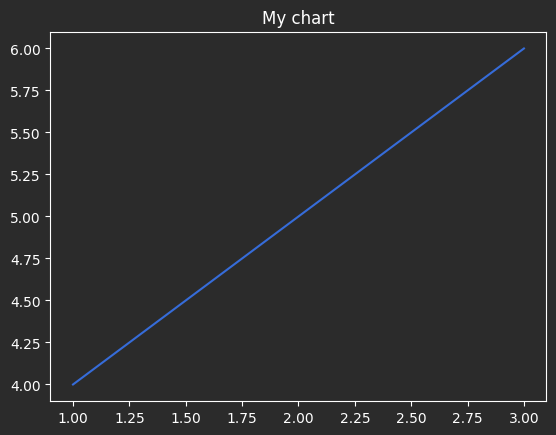

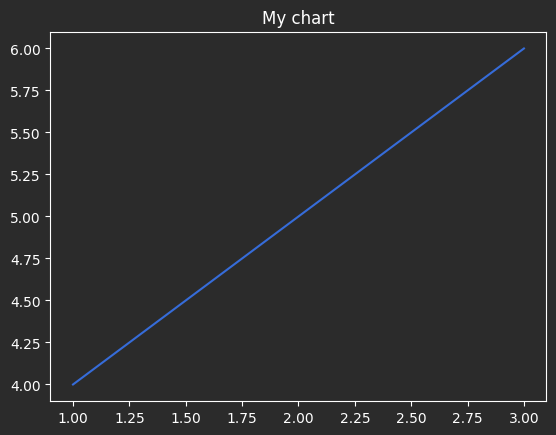

In [3]:
## 3
# Style 1 — pyplot (state machine). Looks easier, scales terribly.
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("My chart")
plt.show()

# Style 2 — OOP (what we use). Explicit, scales perfectly.
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("My chart")
plt.show()

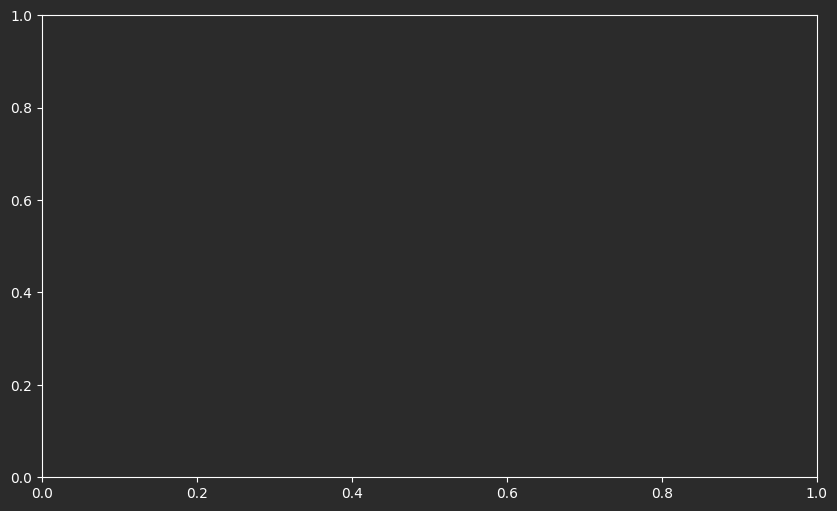

In [4]:
## 4
fig, ax = plt.subplots(figsize=(10,6))
plt.show()

"Which validator is catching the most errors?"

In [5]:
## 5
# Step 1-4: prep the data
errors_per_validator = (
df.query("validation_status == 'FLAGGED'")
    ['error_codes']
    .str.split(', ')
    .explode()
    .str.extract(r'^([A-Z]+)', expand=False)
    .value_counts()
)

errors_per_validator

error_codes
LEI     92
SHIP    45
AMT     27
XVAL    24
DATE    17
LC      14
BIC     11
PTY      7
Name: count, dtype: int64

---Draw it---

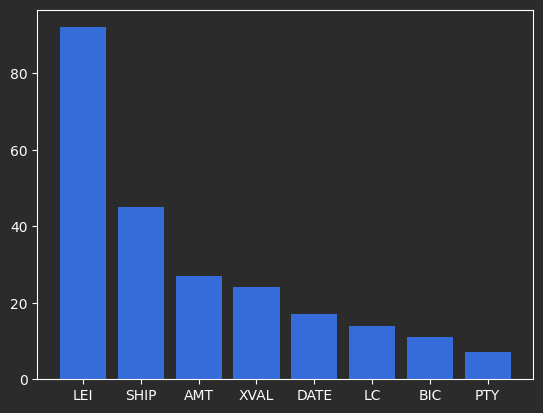

'06006\nfig, ax = plt.subplots()\nax.SOMETHING(x_data, y_data)   # ← .bar, .plot, .scatter, .hist...\nplt.show()\n'

In [6]:
## 6
fig, ax = plt.subplots()
ax.bar(errors_per_validator.index, errors_per_validator.values)
plt.show()

"""06006
fig, ax = plt.subplots()
ax.SOMETHING(x_data, y_data)   # ← .bar, .plot, .scatter, .hist...
plt.show()
"""

Making it presentation-ready

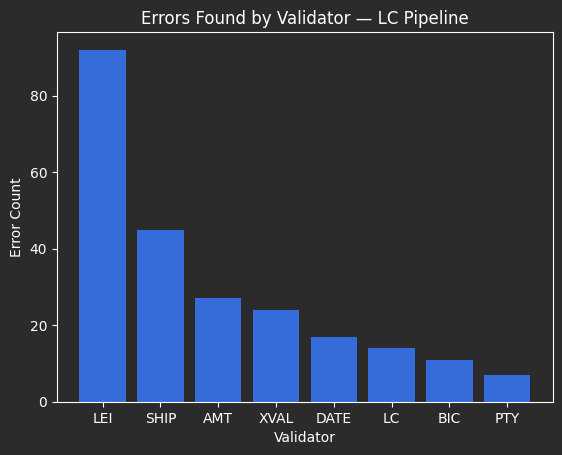

In [7]:
## 7
fig, ax = plt.subplots()
ax.bar(errors_per_validator.index, errors_per_validator.values)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

plt.show()

Color coding by severity

In [8]:
## 8
from config.validation_rules import ALL_ERROR_CODES

# Step 1: Build a DataFrame from the source of truth
severity_map = pd.DataFrame([
    {'error_code': code, 'severity': info['severity']}
    for code, info in ALL_ERROR_CODES.items()
])

# Step 2 Add the validator prefix
severity_map['validator'] = severity_map['error_code'].str.extract(r'^([A-Z]+)')

severity_map.head()


,error_code,severity,validator
0,AMT001,CRITICAL,AMT
1,AMT002,CRITICAL,AMT
2,AMT003,HIGH,AMT
3,AMT004,HIGH,AMT
4,AMT005,CRITICAL,AMT


Most common severity per validator

In [9]:
## 9
validator_severity = (
    severity_map
    .groupby('validator')['severity']
    .agg(lambda s: s.mode().iloc[0])
)

validator_severity

validator
AMT     CRITICAL
BIC         HIGH
DATE        HIGH
LC      CRITICAL
LEI         HIGH
PTY       MEDIUM
SHIP        HIGH
XVAL    CRITICAL
Name: severity, dtype: str

Paint the bars

In [10]:
## 10
# Reindex validator_severity to match the chart's bar order, then map to colors
bar_colors = (          # two Series with different sort orders
    validator_severity # ( cell #9) → sorted alphabetically by groupby: AMT, BIC, DATE, LC, LEI, PTY, SHIP, XVAL
    .reindex(errors_per_validator.index)  # (cell #5) → sorted by frequency (most errors first): LEI, SHIP, AMT, XVAL, DATE, LC, BIC, PTY
    .map(SEVERITY_COLORS)
    .tolist()
)
# The bars on the chart follow errors_per_validator's order. If you just mapped colors from validator_severity,
# the colors would be misaligned — LEI's bar would get AMT's color.

# reindex ->  Reorders validator_severity to match the bar chart's order.

bar_colors

['#DC143C',
 '#DC143C',
 '#8B0000',
 '#8B0000',
 '#DC143C',
 '#8B0000',
 '#DC143C',
 '#FFA500']

The final chart

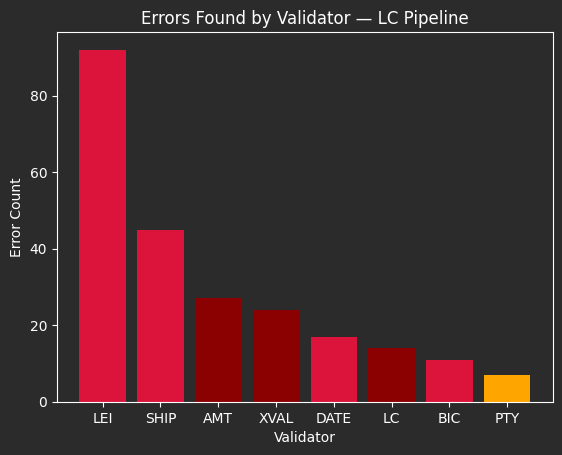

In [11]:
## 11
fig, ax = plt.subplots()
ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

plt.show()

The legend

The pattern: Patch proxies

In [12]:
## 12
from matplotlib.patches import Patch

# Build one Patch per severity level that actually appears in our chart
unique_severities = validator_severity.reindex(errors_per_validator.index).unique()

legend_elements = [
    Patch(facecolor=SEVERITY_COLORS[sev], label=sev)
    for sev in unique_severities
]


The full chart with legend

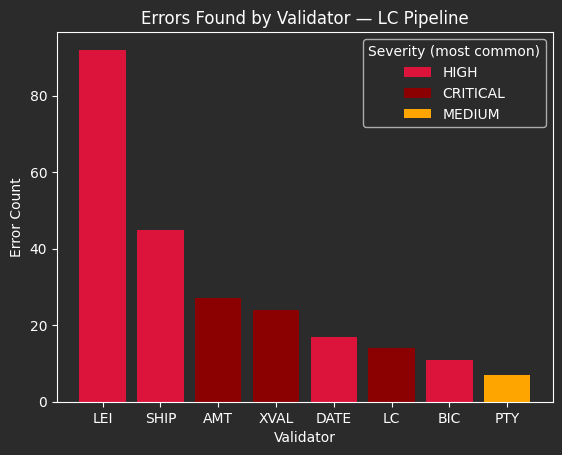

In [13]:
## 13
# _ loc='best'
fig, ax = plt.subplots()
ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

ax.legend(handles=legend_elements, title='Severity (most common)')

plt.show()

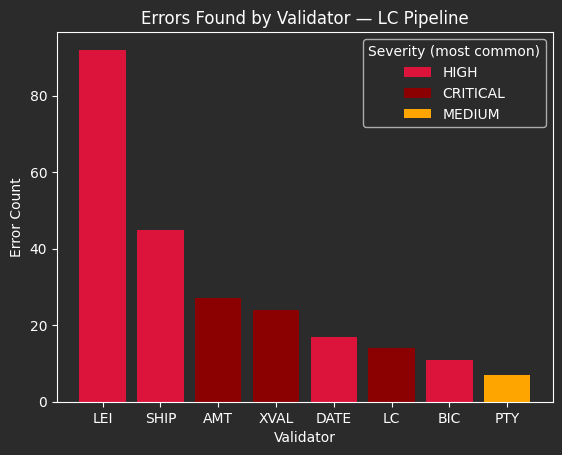

In [14]:
## 14 — Quick: force legend position
# _ loc='upper right'
fig, ax = plt.subplots()
ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

ax.legend(handles=legend_elements, title='Severity (most common)', loc='upper right')

plt.show()

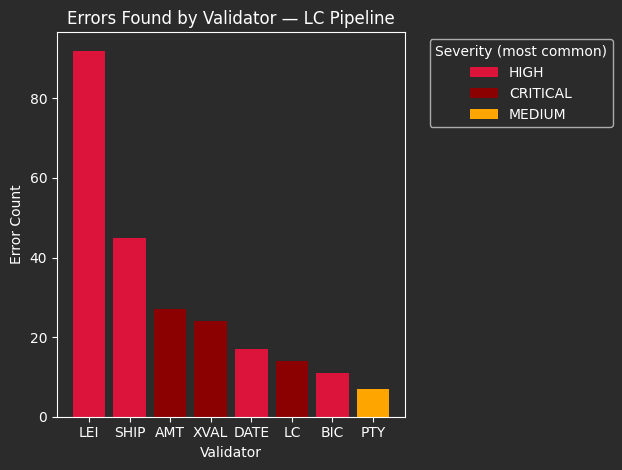

In [15]:
## 15 — Pro: legend outside the chart
# _ bbox_to_anchor
fig, ax = plt.subplots()
ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

ax.legend(handles=legend_elements, title='Severity (most common)',
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## DAY 67

figsize — controlling chart dimensions

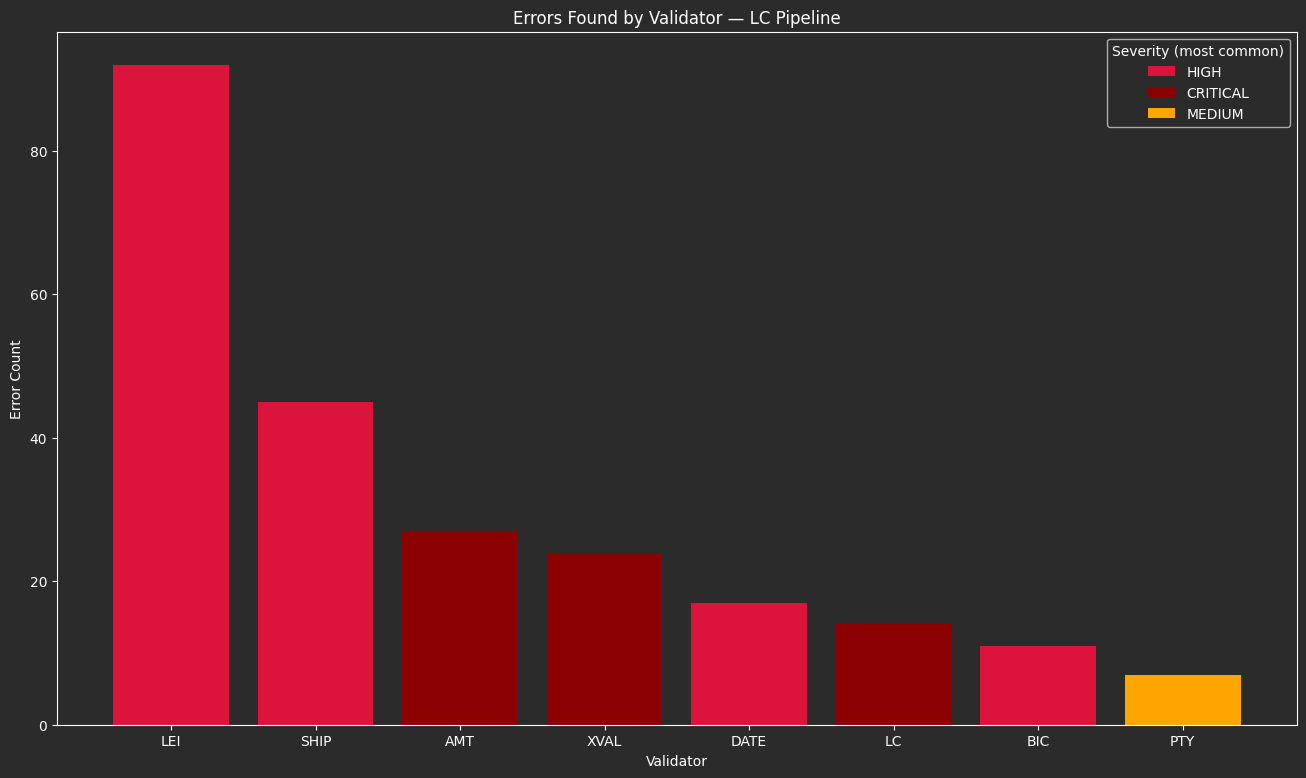

In [16]:
## 16
#  default size matplotlib picked (~6.4 × 4.8 inches)
# fig,ax = plt.subplots(figsize = (10,6))

# _ loc='upper right'
fig, ax = plt.subplots(figsize = (16,9))
ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

ax.legend(handles=legend_elements, title='Severity (most common)', loc='upper right')

plt.show()

The pattern: ax.bar_label()

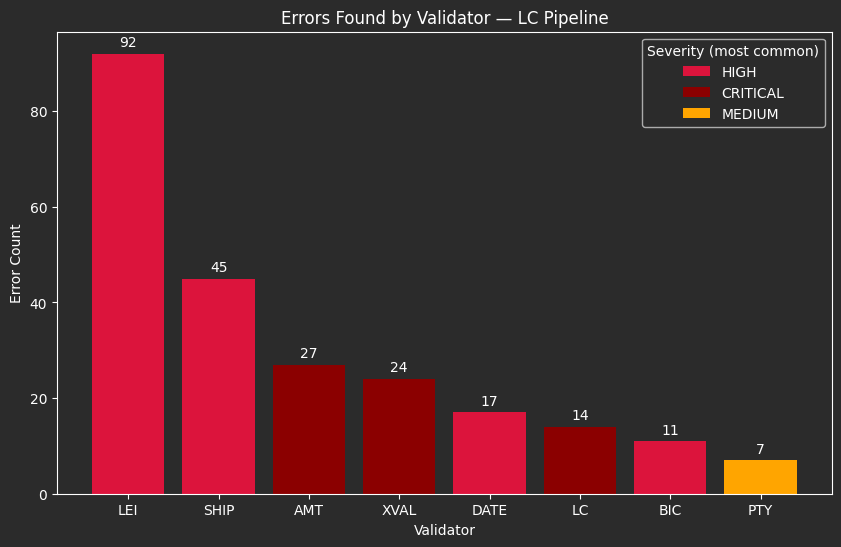

In [17]:
## 17
fig, ax = plt.subplots(figsize=(10, 6))

# ax.bar(...) doesn't just draw — it returns an object called a BarContainer
# You store it in bars so you can hand it to ax.bar_label() on the next line
bars = ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors) # now you hold the reference
ax.bar_label(bars, padding=3)  # ← now matplotlib knows which bars to label

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')
ax.legend(handles=legend_elements, title='Severity (most common)', loc='upper right')

plt.show()


: Saving to file

In [18]:
## 18
fig.savefig('errors_by_validator.png', dpi=300, bbox_inches='tight')

where the .pgn file goes ?

In [19]:
## 19
fig.savefig('../data/output/errors_by_validator.png', dpi=300, bbox_inches='tight')

In production code (not exploration), you'd use pathlib:
"""
from config import settings
output_path = settings.OUTPUT_DIR / 'errors_by_validator.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
"""


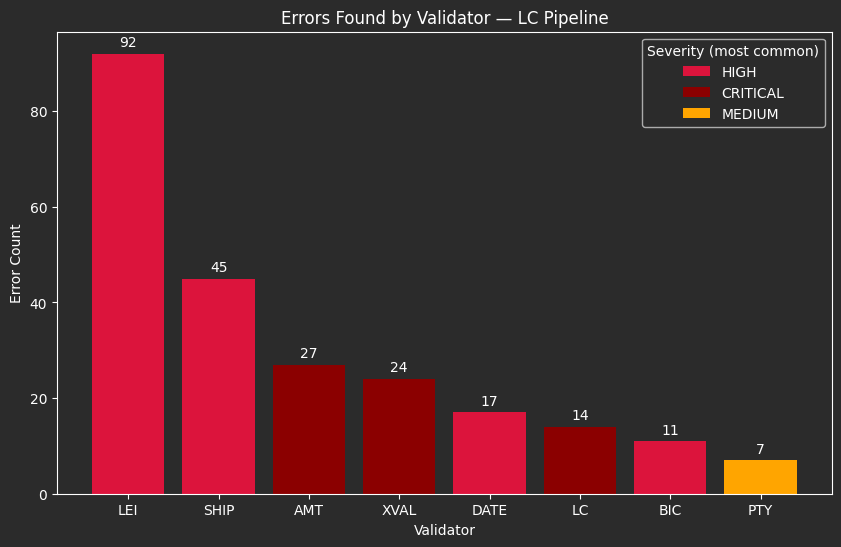

In [20]:
## 20
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)
ax.bar_label(bars, padding=3)

ax.set_title('Errors Found by Validator — LC Pipeline')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')
ax.legend(handles=legend_elements, title='Severity (most common)', loc='upper right')

fig.savefig('../data/output/errors_by_validator.png', dpi=300, bbox_inches='tight')

plt.show()   # figure rendered + cleared



## Day 68 — Subplots: Multiple Charts, One Figure

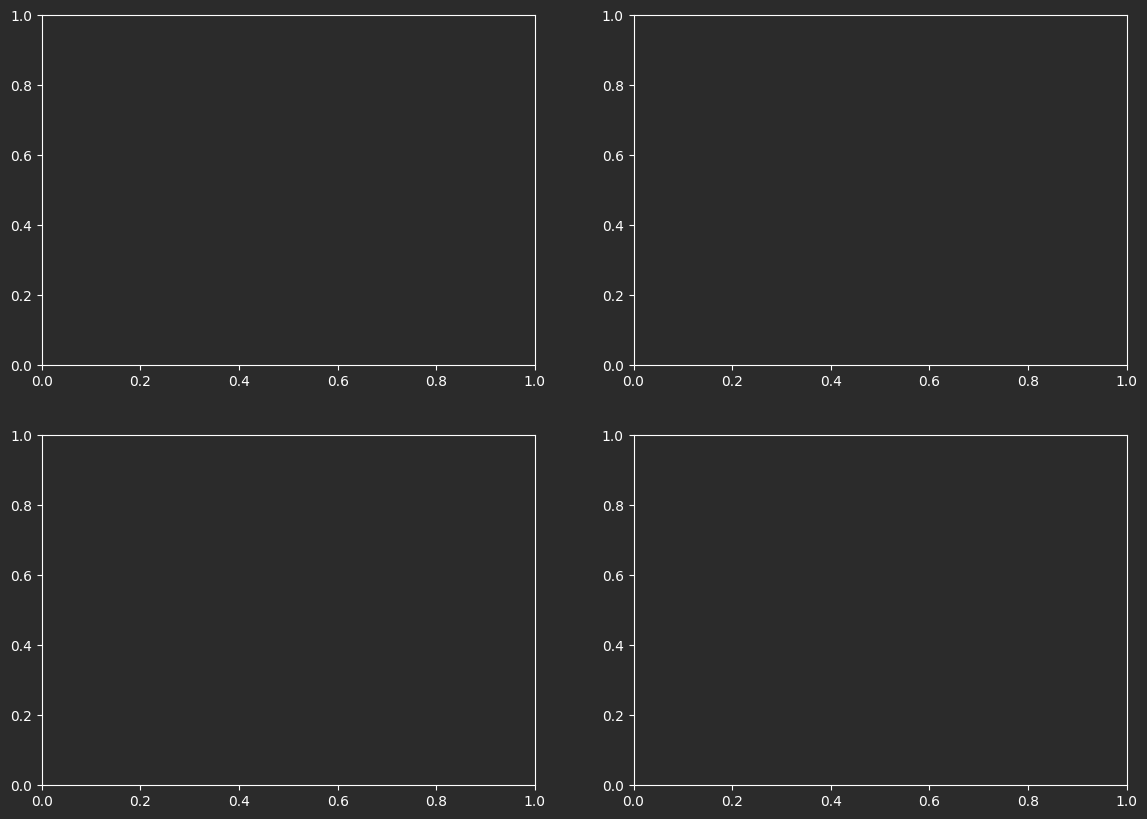

In [21]:
## 21

fig, axes = plt.subplots(2,2 ,figsize=(14,10))


Plan the four stories

In [22]:
## 22
status_counts = df['validation_status'].value_counts()

axes[0, 1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#DC143C', '#28A745'],      # Flagged = red, Clean = green
    autopct='%1.0f%%',                   # Show percentage inside each slice
    startangle=90,                       # Start from 12 o'clock
    wedgeprops={'width': 0.4}            # The magic that makes it a donut!
)
axes[0, 1].set_title('Clean vs Flagged (200 LCs)')




Text(0.5, 1.0, 'Clean vs Flagged (200 LCs)')

 The donut — Clean vs Flagged

In [23]:
## 23
status_counts = df['validation_status'].value_counts()
status_counts

validation_status
FLAGGED    128
CLEAN       72
Name: count, dtype: int64

The code

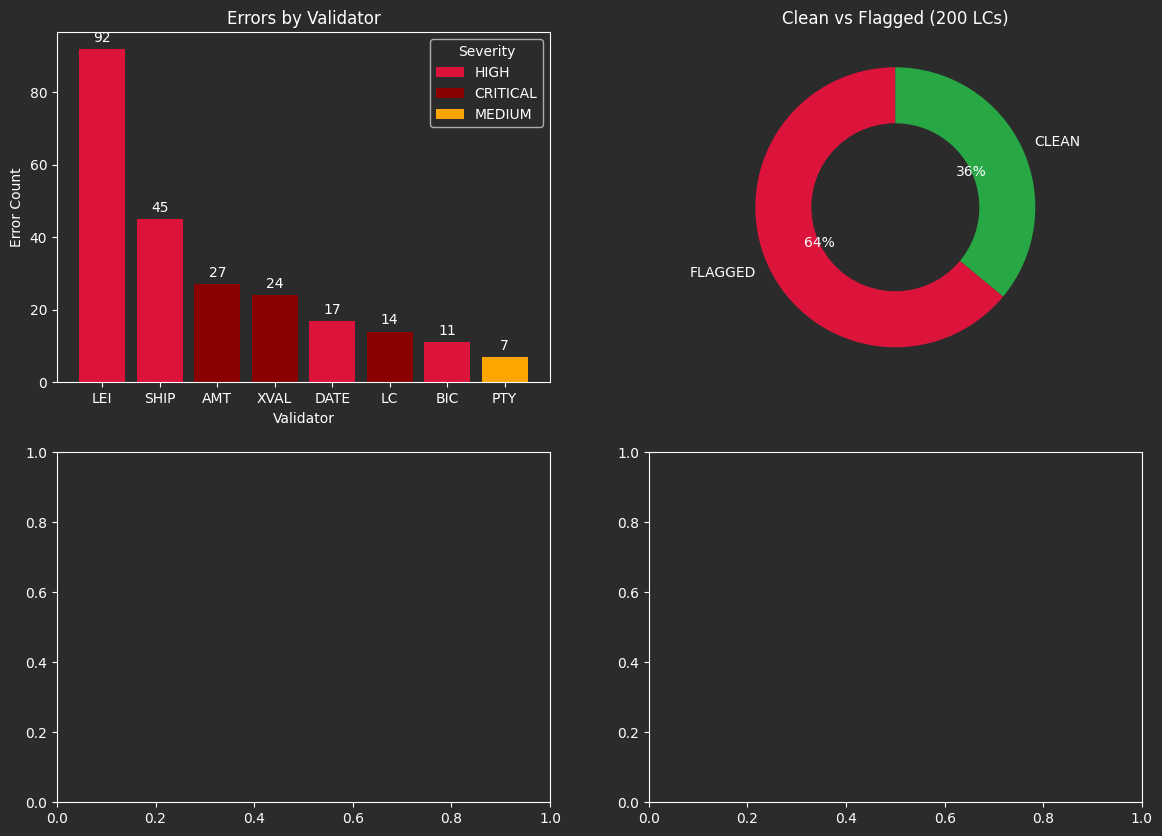

In [24]:
## 24

# THE DASHBOARD CELL — everything here together
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: validator bars
bars = axes[0, 0].bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)
axes[0, 0].bar_label(bars, padding=3)
axes[0, 0].set_title('Errors by Validator')
axes[0, 0].set_xlabel('Validator')
axes[0, 0].set_ylabel('Error Count')
axes[0, 0].legend(handles=legend_elements, title='Severity', loc='upper right')


# Top-right: donut
axes[0, 1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#DC143C', '#28A745'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
axes[0, 1].set_title('Clean vs Flagged (200 LCs)')

plt.show()


 Severity breakdown  "Of all 237 errors, how urgent are they?"


In [25]:
## 25

# Get severity for EVERY error code (one row per error)
flagged_errors = (
    df.query("validation_status == 'FLAGGED'")
      ['error_codes']
      .str.split(', ')
      .explode()
)

# Map each error to its severity from the source of truth
error_severity_map = {code: info['severity'] for code, info in ALL_ERROR_CODES.items()}

severity_counts = flagged_errors.map(error_severity_map).value_counts()
severity_counts



error_codes
HIGH        158
CRITICAL     45
MEDIUM       31
LOW           3
Name: count, dtype: int64

The chart
Same ax.bar() pattern as yesterday, but applied to axes[1, 0]:

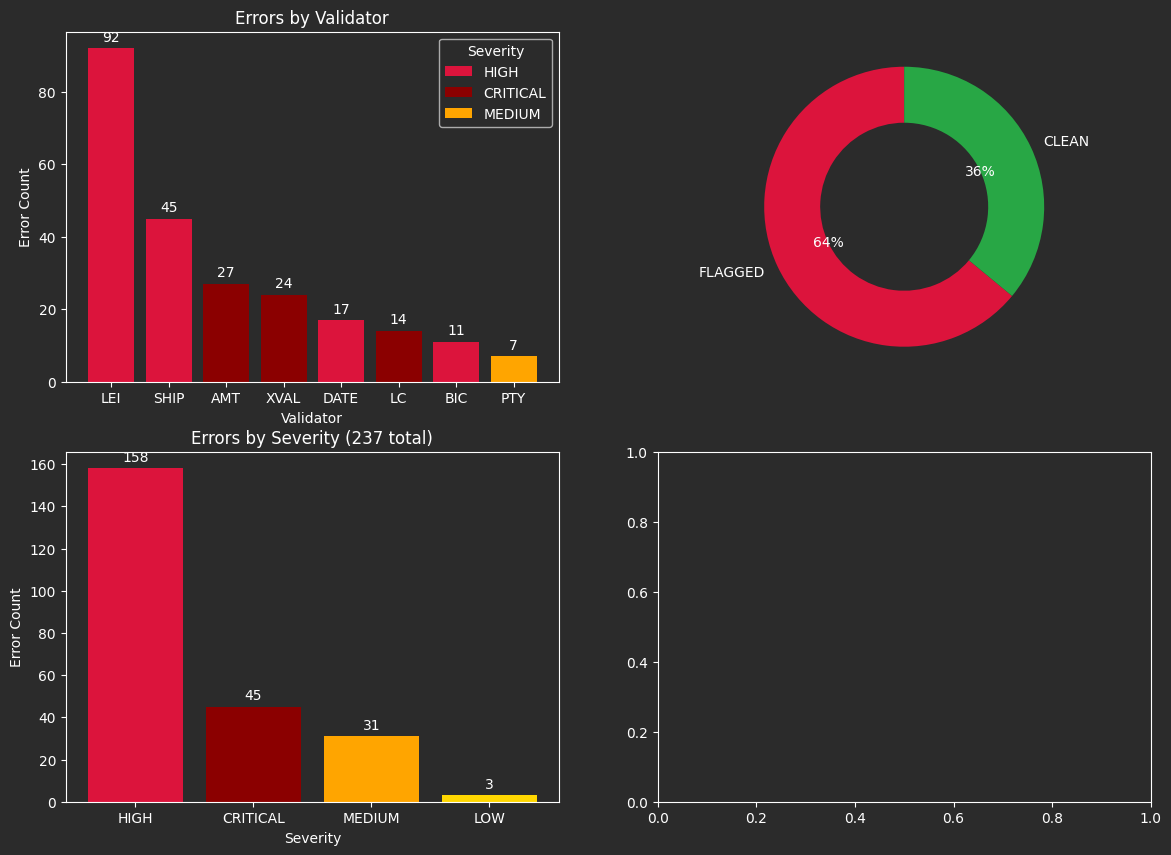

In [26]:
## 26
# Match colors to severities, in the order they appear
severity_bar_colors = [SEVERITY_COLORS[sev] for sev in severity_counts.index]
# THE DASHBOARD CELL — everything here together
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: validator bars
bars = axes[0, 0].bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)
axes[0, 0].bar_label(bars, padding=3)
axes[0, 0].set_title('Errors by Validator')
axes[0, 0].set_xlabel('Validator')
axes[0, 0].set_ylabel('Error Count')
axes[0, 0].legend(handles=legend_elements, title='Severity', loc='upper right')


# Top-right: donut
axes[0, 1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#DC143C', '#28A745'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
bars2 = axes[1, 0].bar(severity_counts.index, severity_counts.values, color=severity_bar_colors)
axes[1, 0].bar_label(bars2, padding=3)
axes[1, 0].set_title('Errors by Severity (237 total)')
axes[1, 0].set_xlabel('Severity')
axes[1, 0].set_ylabel('Error Count')

plt.show()

 The final subplot — Country breakdown

In [27]:
## 27
flagged_by_country = (
    df.query("validation_status == 'FLAGGED'")
      ['applicant_country']
      .value_counts()
      .head(10)        # Top 10 only — keep chart readable
      .sort_values()   # Ascending — biggest bar at top after horizontal flip
)
flagged_by_country

applicant_country
XX     1
GB     5
TW     9
JP    14
CH    16
DE    19
KR    24
US    40
Name: count, dtype: int64

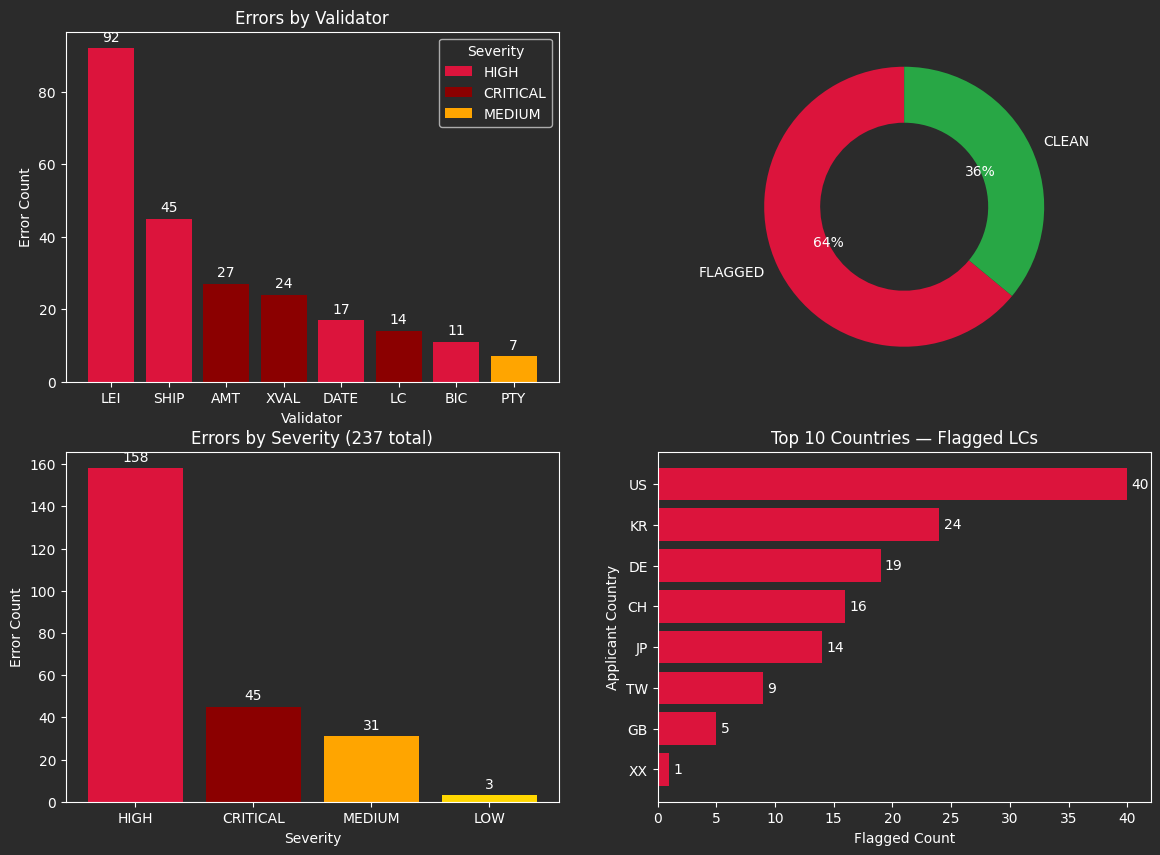

In [28]:
## 28

# THE DASHBOARD CELL — everything here together
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: validator bars
bars = axes[0, 0].bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)
axes[0, 0].bar_label(bars, padding=3)
axes[0, 0].set_title('Errors by Validator')
axes[0, 0].set_xlabel('Validator')
axes[0, 0].set_ylabel('Error Count')
axes[0, 0].legend(handles=legend_elements, title='Severity', loc='upper right')


# Top-right: donut
axes[0, 1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#DC143C', '#28A745'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
bars2 = axes[1, 0].bar(severity_counts.index, severity_counts.values, color=severity_bar_colors)
axes[1, 0].bar_label(bars2, padding=3)
axes[1, 0].set_title('Errors by Severity (237 total)')
axes[1, 0].set_xlabel('Severity')
axes[1, 0].set_ylabel('Error Count')


axes[1, 1].barh(
    flagged_by_country.index,
    flagged_by_country.values,
    color='#DC143C'     # All same color — country isn't a severity dimension
)
axes[1, 1].bar_label(axes[1, 1].containers[0], padding=3)
axes[1, 1].set_title('Top 10 Countries — Flagged LCs')
axes[1, 1].set_xlabel('Flagged Count')
axes[1, 1].set_ylabel('Applicant Country')

plt.show()

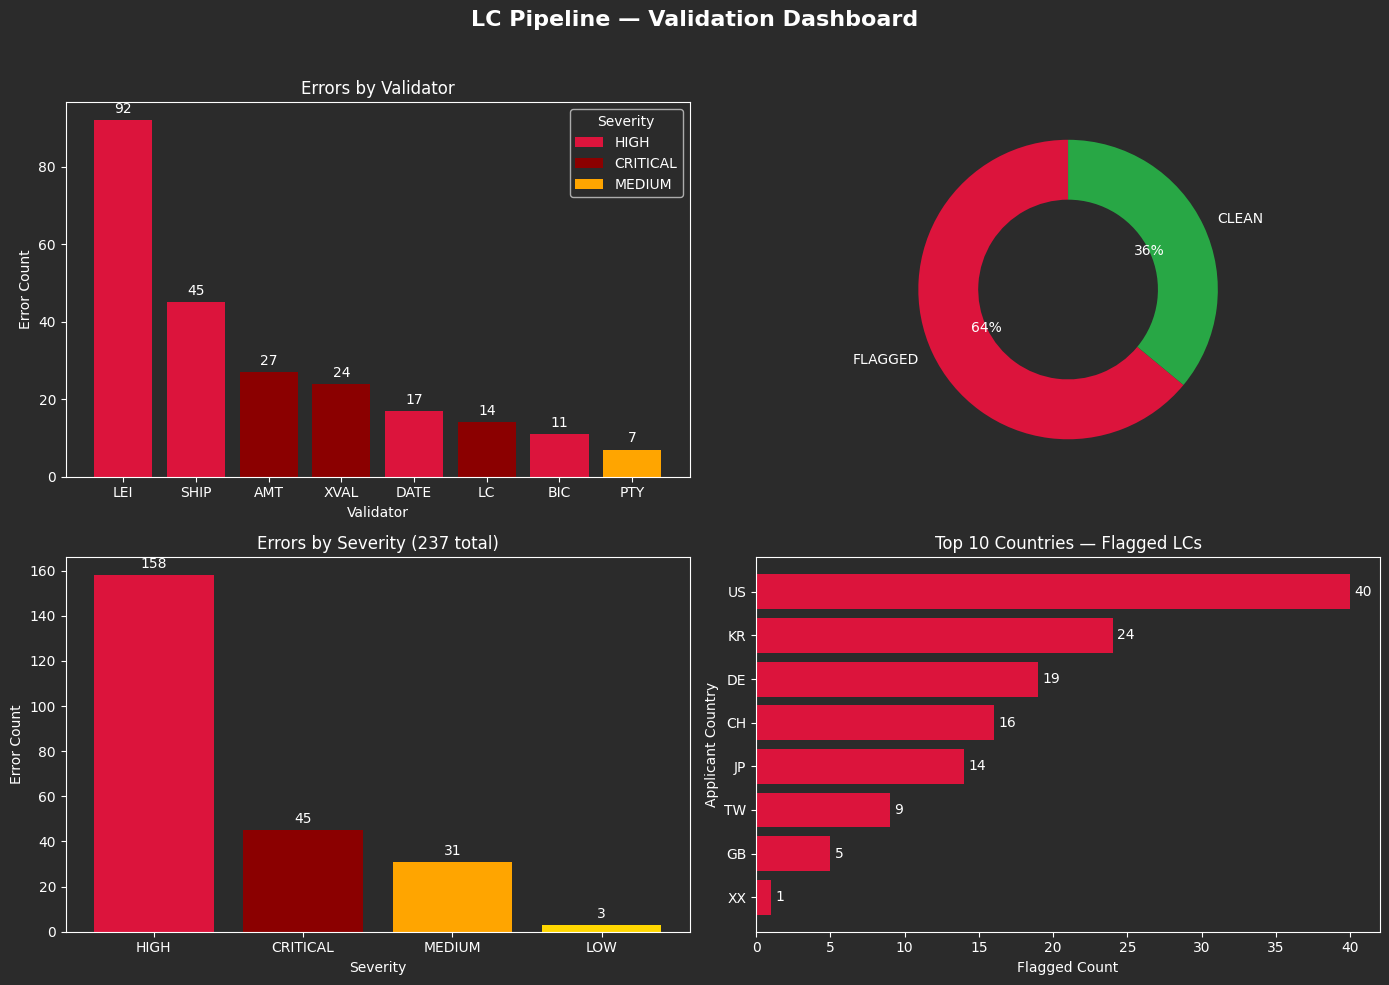

In [29]:
## 29
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: validator bars
bars = axes[0, 0].bar(errors_per_validator.index, errors_per_validator.values, color=bar_colors)
axes[0, 0].bar_label(bars, padding=3)
axes[0, 0].set_title('Errors by Validator')
axes[0, 0].set_xlabel('Validator')
axes[0, 0].set_ylabel('Error Count')
axes[0, 0].legend(handles=legend_elements, title='Severity', loc='upper right')


# Top-right: donut
axes[0, 1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#DC143C', '#28A745'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
bars2 = axes[1, 0].bar(severity_counts.index, severity_counts.values, color=severity_bar_colors)
axes[1, 0].bar_label(bars2, padding=3)
axes[1, 0].set_title('Errors by Severity (237 total)')
axes[1, 0].set_xlabel('Severity')
axes[1, 0].set_ylabel('Error Count')


axes[1, 1].barh(
    flagged_by_country.index,
    flagged_by_country.values,
    color='#DC143C'     # All same color — country isn't a severity dimension
)
axes[1, 1].bar_label(axes[1, 1].containers[0], padding=3)
axes[1, 1].set_title('Top 10 Countries — Flagged LCs')
axes[1, 1].set_xlabel('Flagged Count')
axes[1, 1].set_ylabel('Applicant Country')

fig.suptitle('LC Pipeline — Validation Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [30]:
## 30
fig.savefig('../data/output/dashboard_v1.png', dpi=300, bbox_inches='tight')

## DAY 69  Distributions: Histograms & Boxplots

In [31]:
## 31
# df['amount'].describe()
# df['amount'].astype(float).describe()
# pd.to_numeric(df['amount'], errors='coerce').describe()
amount = pd.to_numeric(df['amount'], errors='coerce')
amount.describe()



count    9.300000e+01
mean     2.349195e+08
std      1.455606e+09
min     -5.000000e+04
25%      4.899627e+06
50%      2.069082e+07
75%      3.627773e+07
max      1.000000e+10
Name: amount, dtype: float64

THe Chart

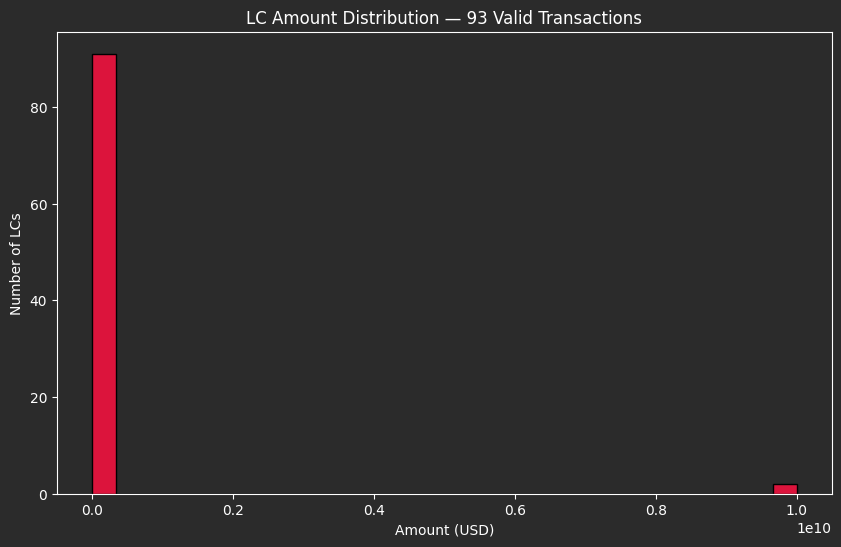

In [32]:
## 32
amount_clean = pd.to_numeric(df['amount'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(amount_clean.dropna(), bins=30, color='#DC143C', edgecolor='black')

ax.set_title('LC Amount Distribution — 93 Valid Transactions')
ax.set_xlabel('Amount (USD)')
ax.set_ylabel('Number of LCs')

plt.show()


In [33]:
## 33
# What's in the amount column? Show raw dtype
print("dtype:", df['amount'].dtype)

# How many values fail numeric conversion?
converted = pd.to_numeric(df['amount'], errors='coerce')
print(f"Total rows: {len(df)}")
print(f"Converted successfully: {converted.notna().sum()}")
print(f"NaN after coercion: {converted.isna().sum()}")

# Show examples of what FAILED conversion
failed_mask = converted.isna() & df['amount'].notna()
print("\nSamples that failed numeric conversion:")
print(df.loc[failed_mask, 'amount'].head(10))

dtype: str
Total rows: 200
Converted successfully: 93
NaN after coercion: 107

Samples that failed numeric conversion:
0     49,543,534.00
1        43,942,455
2        701,960.00
5     44,698,977.00
6     29,573,500.00
7      6,721,792.00
8      4,994,878.00
11    10,393,710.00
12    16,565,922.00
14    13,300,487.00
Name: amount, dtype: str


In [34]:
## 34
# Strip commas, then convert to numeric
amount_clean = (
    df['amount']
    .str.replace(',', '', regex=False)    # Remove ALL commas
    .pipe(pd.to_numeric, errors='coerce') # THEN convert
)

# amount_clean = pd.to_numeric(df['amount'].str.replace(',', '', regex=False), errors='coerce')

print(f"Converted successfully: {amount_clean.notna().sum()}")
print(f"Still NaN: {amount_clean.isna().sum()}")
amount_clean.describe()

Converted successfully: 199
Still NaN: 1


count    1.990000e+02
mean     1.215143e+08
std      9.979774e+08
min     -5.000000e+04
25%      6.624816e+06
50%      1.869548e+07
75%      3.636502e+07
max      1.000000e+10
Name: amount, dtype: float64

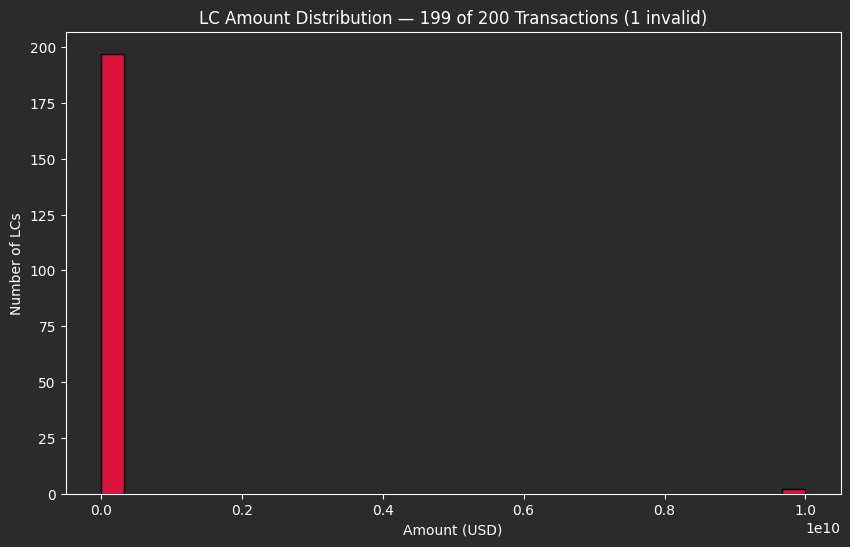

In [35]:
## 35
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(amount_clean.dropna(), bins=30, color='#DC143C', edgecolor='black')

ax.set_title('LC Amount Distribution — 199 of 200 Transactions (1 invalid)')
ax.set_xlabel('Amount (USD)')
ax.set_ylabel('Number of LCs')

plt.show()

Strategy 1: Trim the outlier (simplest)
Question: "What does the NORMAL LC distribution look like?"

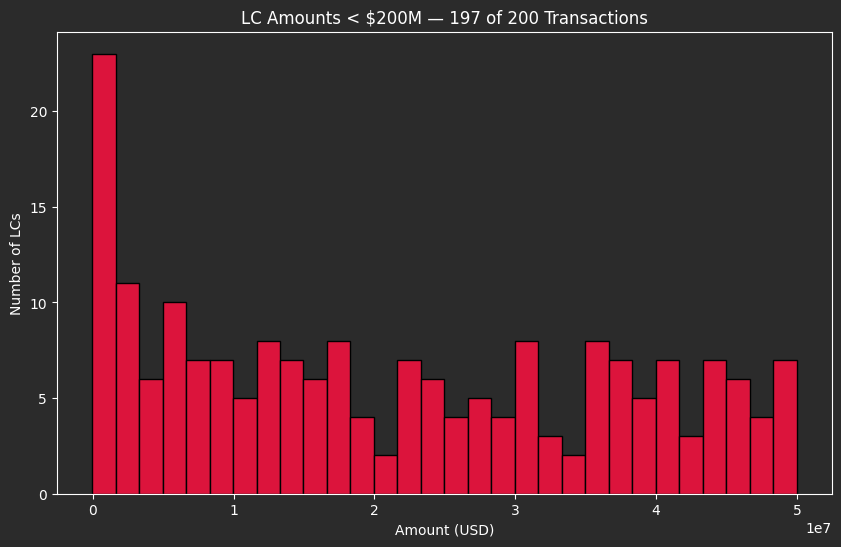

In [36]:
## 36
## Keep only LCs under $200M — the sensible upper bound
amount_normal = amount_clean[amount_clean < 200_000_000].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(amount_normal, bins=30, color='#DC143C', edgecolor='black')
ax.set_title(f'LC Amounts < $200M — {len(amount_normal)} of 200 Transactions')
ax.set_xlabel('Amount (USD)')
ax.set_ylabel('Number of LCs')
plt.show()

Strategy 2: Log scale (my favorite for banking)
Question: "Show me ALL the data at a readable scale.

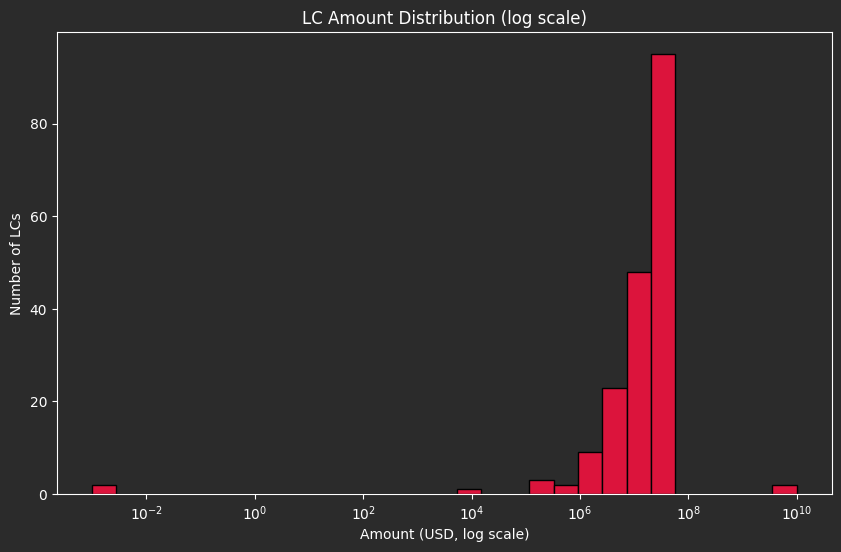

In [37]:
## 37
fig, ax = plt.subplots(figsize=(10, 6))

#_ Log bins — bins spaced logarithmically
import numpy as np
positive_amounts = amount_clean[amount_clean > 0].dropna()
log_bins = np.logspace(
    np.log10(positive_amounts.min()),
    np.log10(positive_amounts.max()),
    30
)

ax.hist(positive_amounts, bins=log_bins, color='#DC143C', edgecolor='black')
ax.set_xscale('log')    # Log scale X-axis
ax.set_title('LC Amount Distribution (log scale)')
ax.set_xlabel('Amount (USD, log scale)')
ax.set_ylabel('Number of LCs')
plt.show()


Strategy 3: Percentile filter (the regulatory-safe option)
Question: "Show me the middle of the distribution, keeping outliers in the dataset but off-screen."

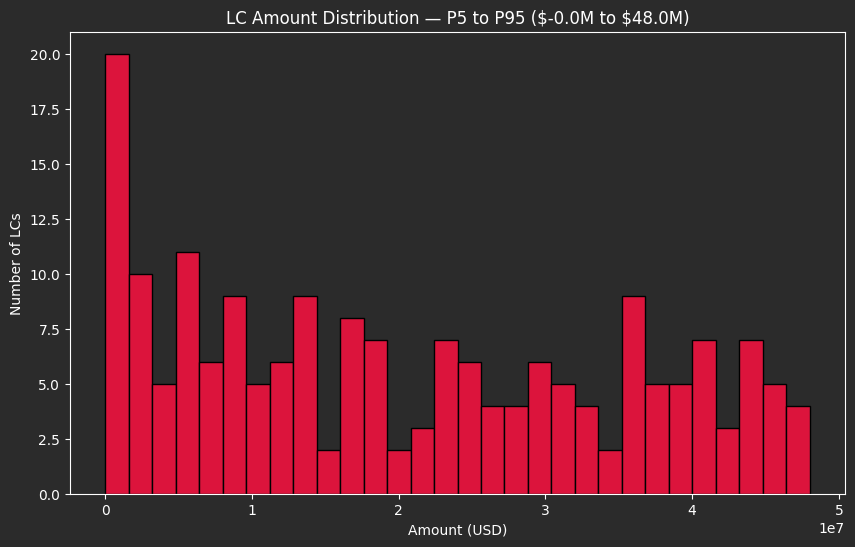

In [38]:
## 38
#_ Keep values between P5 and P95
p5 = amount_clean.quantile(0.05)
p95 = amount_clean.quantile(0.95)

amount_middle = amount_clean[(amount_clean >= p5) & (amount_clean <= p95)].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(amount_middle, bins=30, color='#DC143C', edgecolor='black')
ax.set_title(rf'LC Amount Distribution — P5 to P95 (\${p5/1e6:.1f}M to \${p95/1e6:.1f}M)')
ax.set_xlabel('Amount (USD)')
ax.set_ylabel('Number of LCs')
plt.show()

##  Boxplots — The Five-Number Summary

The 1.5 × IQR rule (the whisker logic)

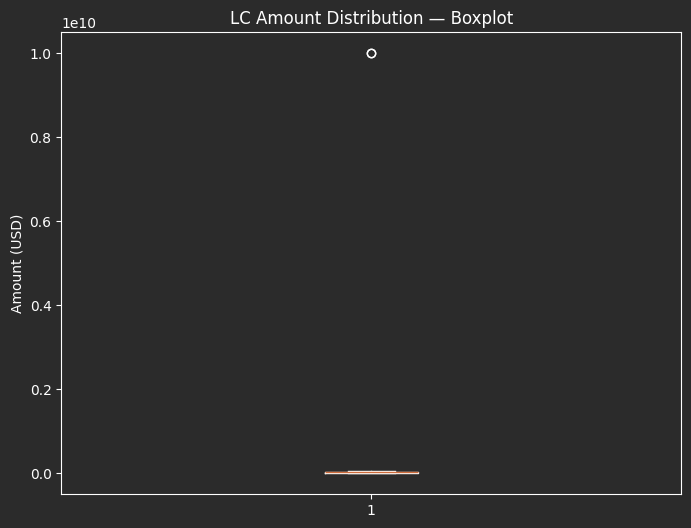

In [39]:
## 39
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(amount_clean.dropna(), vert=True)

ax.set_title('LC Amount Distribution — Boxplot')
ax.set_ylabel('Amount (USD)')

plt.show()

Fix the visual — log Y-axis


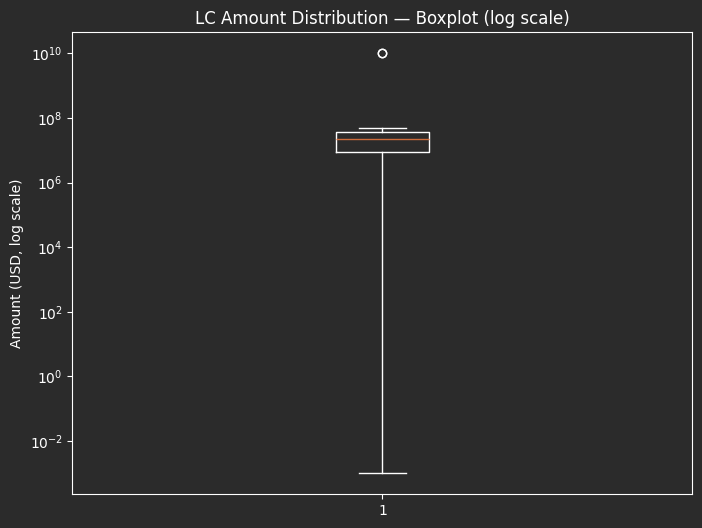

In [40]:
## 40
fig, ax = plt.subplots(figsize=(8, 6))

# Filter to positives only (log can't handle zero or negatives)
positive_amounts = amount_clean[amount_clean > 0].dropna()

ax.boxplot(positive_amounts, vert=True)
ax.set_yscale('log')                   # <-- THE KEY LINE

ax.set_title('LC Amount Distribution — Boxplot (log scale)')
ax.set_ylabel('Amount (USD, log scale)')

plt.show()

The data prep - . Matplotlib needs a list of arrays — one per currency:

In [41]:
## 41
# Filter to valid amounts (positive, parseable)
df_valid = df.copy()
df_valid['amount_clean'] = amount_clean
df_valid = df_valid[df_valid['amount_clean'] > 0].dropna(subset=['amount_clean'])

# Group amounts by currency
currencies = df_valid['currency'].value_counts().head(5).index.tolist()  # Top 5
data_per_currency = [
    df_valid.query('currency == @cur')['amount_clean'].values
    for cur in currencies
]

print(currencies)
print([len(arr) for arr in data_per_currency])

['JPY', 'USD', 'EUR', 'GBP']
[55, 46, 44, 40]


In [42]:
## 42
for cur in currencies:
    amounts = df_valid.query('currency == @cur')['amount_clean']
    print(f"{cur}: median = {amounts.median():,.0f}, max = {amounts.max():,.0f}")

JPY: median = 18,567,802, max = 10,000,000,000
USD: median = 21,689,596, max = 49,963,328
EUR: median = 24,020,032, max = 49,690,891
GBP: median = 22,671,503, max = 10,000,000,000


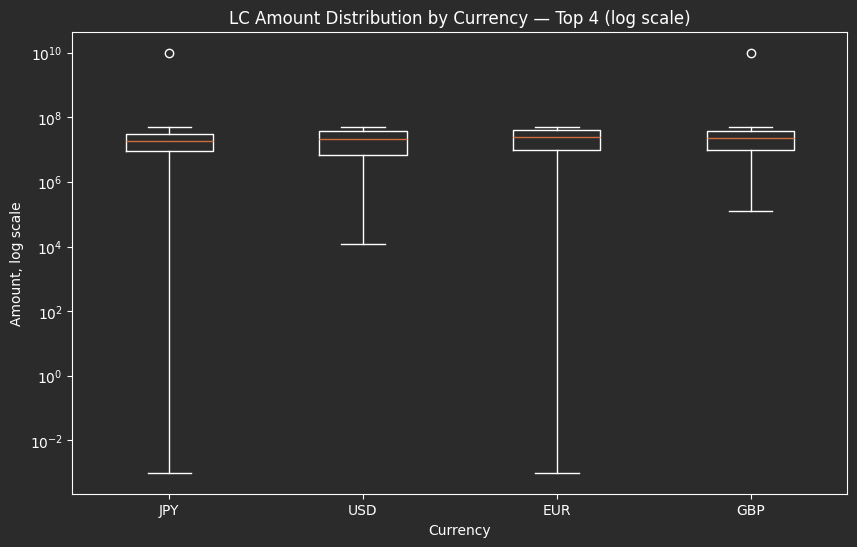

In [43]:
## 43
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(data_per_currency,  tick_labels=currencies, vert=True)
ax.set_yscale('log')

ax.set_title('LC Amount Distribution by Currency — Top 4 (log scale)')
ax.set_xlabel('Currency')
ax.set_ylabel('Amount, log scale')

plt.show()

## Day 70 — Seaborn: Statistical Plotting Done Right

 The setup


In [44]:
##  44
import seaborn as sns
sns.set_theme(style='whitegrid')

 the validator bars


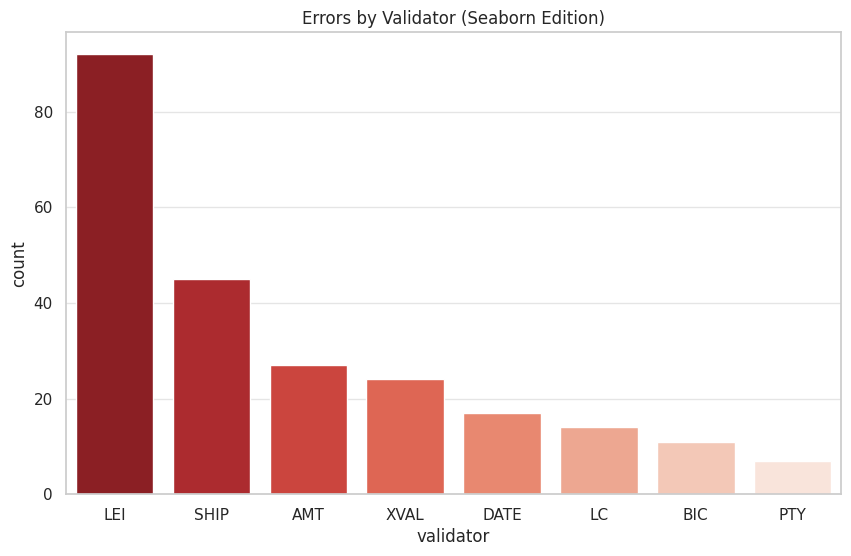

In [45]:
## 45
# Build a long-format DataFrame for seaborn
df_for_chart = errors_per_validator.reset_index()
df_for_chart.columns = ['validator', 'count']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_for_chart, x='validator', y='count', hue='validator', palette='Reds_r', ax=ax, legend=False)
ax.set_title('Errors by Validator (Seaborn Edition)')
plt.show()


Built-in palettes — the real win

In [46]:
## 46
"""
sns.barplot(..., palette='Reds_r')      # Auto-graded reds
sns.barplot(..., palette='viridis')     # Colorblind-safe
sns.barplot(..., palette='RdYlGn_r')    # Red→Yellow→Green (RAG)
"""


"\nsns.barplot(..., palette='Reds_r')      # Auto-graded reds\nsns.barplot(..., palette='viridis')     # Colorblind-safe\nsns.barplot(..., palette='RdYlGn_r')    # Red→Yellow→Green (RAG)\n"

 Heatmaps — seaborn's killer chart

In [47]:
## 47
import re
from itertools import combinations
from collections import Counter

errors_per_tx = (
    df.query("validation_status == 'FLAGGED'")
      ['error_codes']
      .str.split(', ')
)

pair_counts = Counter()

for codes in errors_per_tx:
    # Extract validator prefix from each code (LEI004 → LEI)
    validators_in_tx = sorted(set(re.match(r'^([A-Z]+)', code).group(1) for code in codes))
    # Count co-occurring pairs
    for a, b in combinations(validators_in_tx, 2):
        pair_counts[(a, b)] += 1

print(pair_counts.most_common(10))

[(('LEI', 'SHIP'), 25), (('AMT', 'LEI'), 17), (('LEI', 'XVAL'), 12), (('AMT', 'SHIP'), 11), (('LC', 'LEI'), 9), (('DATE', 'LEI'), 7), (('SHIP', 'XVAL'), 7), (('AMT', 'XVAL'), 6), (('LC', 'SHIP'), 5), (('BIC', 'LEI'), 5)]


Building the matrix


In [48]:
## 48
import pandas as pd

# Get the list of all validator prefixes that appear in your data
all_validators = sorted({v for pair in pair_counts for v in pair})


# Build a long-format DataFrame from the Counter
pair_df = pd.DataFrame([
    {'validator_a': a, 'validator_b': b, 'count': n}
    for (a, b), n in pair_counts.items()
])

# Pivot to get a square matrix
matrix = pair_df.pivot(index='validator_a', columns='validator_b', values='count').fillna(0)

# Make it symmetric (AMT-LEI and LEI-AMT should be equal)
matrix = matrix.add(matrix.T, fill_value=0)

# Force the order of rows and columns to match
matrix = matrix.reindex(index=all_validators, columns=all_validators, fill_value=0)
matrix = matrix.fillna(0).astype(int)
print(matrix)


validator_b  AMT  BIC  DATE  LC  LEI  PTY  SHIP  XVAL
validator_a                                          
AMT            0    0     1   4   17    1    11     6
BIC            0    0     0   2    5    0     1     0
DATE           1    0     0   0    7    0     4     2
LC             4    2     0   0    9    0     5     1
LEI           17    5     7   9    0    1    25    12
PTY            1    0     0   0    1    0     0     1
SHIP          11    1     4   5   25    0     0     7
XVAL           6    0     2   1   12    1     7     0


Your first heatmap

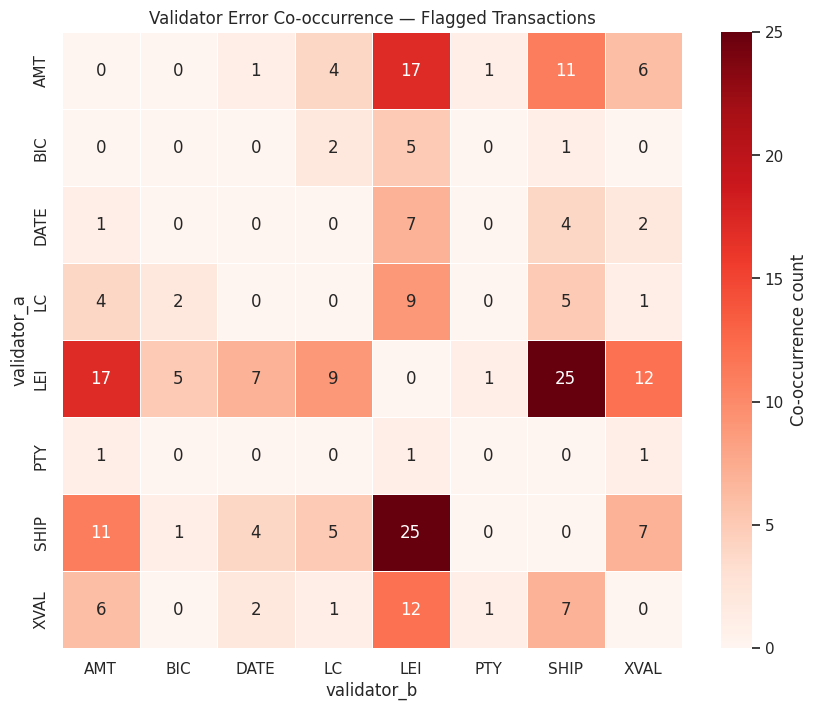

In [49]:
## 49

ig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Reds',
    cbar_kws={'label': 'Co-occurrence count'},
    linewidths=0.5,
    ax=ax
)

ax.set_title('Validator Error Co-occurrence — Flagged Transactions')
plt.show()

 Countplot — the lazy bar chart

With matplotlib it would be:

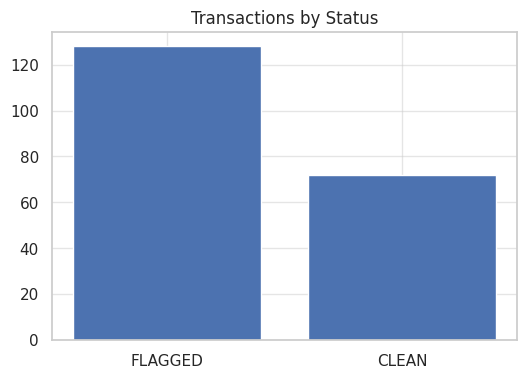

In [50]:
## 50

counts = df['validation_status'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values)
ax.set_title('Transactions by Status')
plt.show()

With seaborn it is:


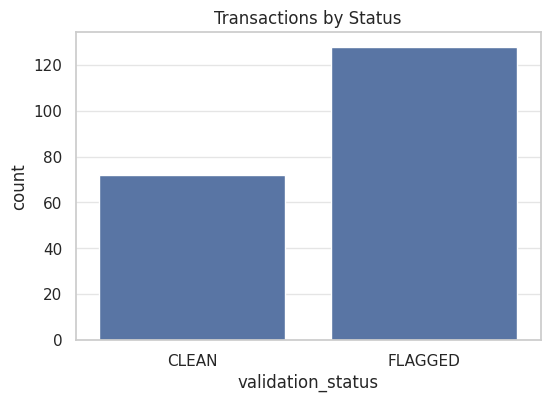

In [51]:
## 51
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='validation_status', ax=ax)
ax.set_title('Transactions by Status')
plt.show()

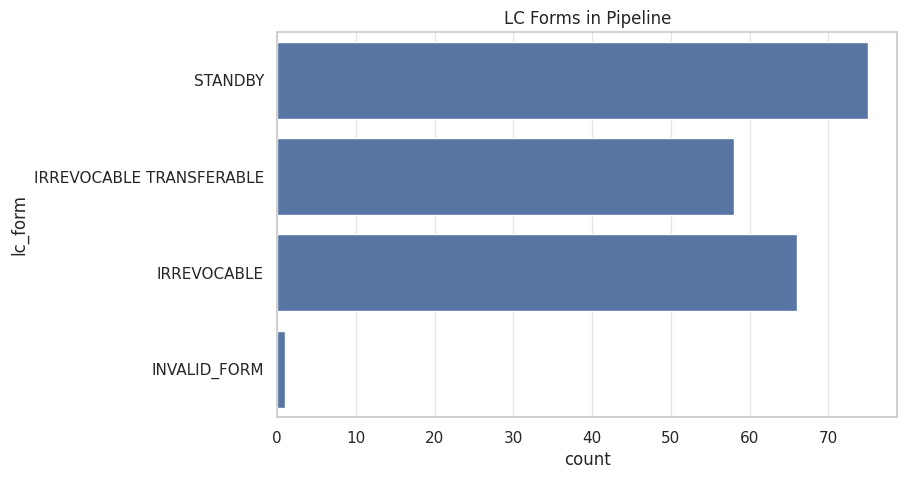

In [52]:
## 52

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, y='lc_form', ax=ax)
ax.set_title('LC Forms in Pipeline')
plt.show()

## Day 71 — Relationships & Time Series

 Scatterplot — finding relationships

In [53]:
## 53

df_scatter = df.copy()
df_scatter['amount_clean'] = amount_clean
df_scatter = df_scatter.query("amount_clean > 0").dropna(subset=['amount_clean', 'error_count'])
print(f"Plotting {len(df_scatter)} transactions")


Plotting 185 transactions


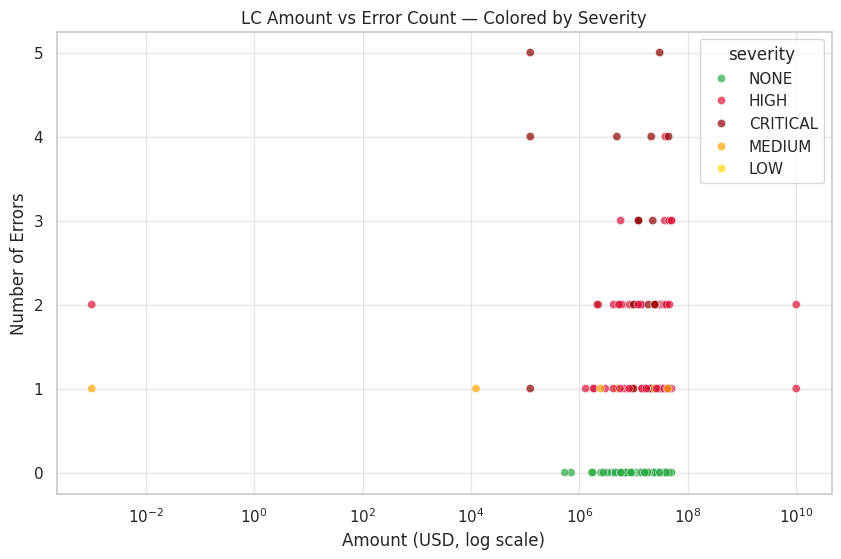

In [54]:
## 54
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter,
    x='amount_clean',
    y='error_count',
    hue='severity',
    palette={'CRITICAL': '#8B0000', 'HIGH': '#DC143C', 'MEDIUM': '#FFA500', 'LOW': '#FFD700', 'NONE': '#28A745'},
    alpha=0.7,
    ax=ax
)

ax.set_xscale('log')
ax.set_title('LC Amount vs Error Count — Colored by Severity')
ax.set_xlabel('Amount (USD, log scale)')
ax.set_ylabel('Number of Errors')
plt.show()

Time series with lineplot

In [55]:
## 55
df_time = df.copy()
df_time['issue_date'] = pd.to_datetime(df_time['issue_date'], errors='coerce')
df_time = df_time.dropna(subset=['issue_date'])

# Group by month and compute flagged percentage
monthly = (
    df_time
    .assign(month=df_time['issue_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')
    .agg(
        total_lcs=('transaction_id', 'count'),
        flagged_lcs=('validation_status', lambda s: (s == 'FLAGGED').sum())
    )
    .assign(flagged_pct=lambda d: d['flagged_lcs'] / d['total_lcs'] * 100)
    .reset_index()
)

print(monthly.head(10))

       month  total_lcs  flagged_lcs  flagged_pct
0 2019-01-01          1            1   100.000000
1 2026-01-01        190          119    62.631579
2 2026-03-01          3            2    66.666667
3 2026-06-01          2            2   100.000000


Lineplot — quick demo with synthetic data

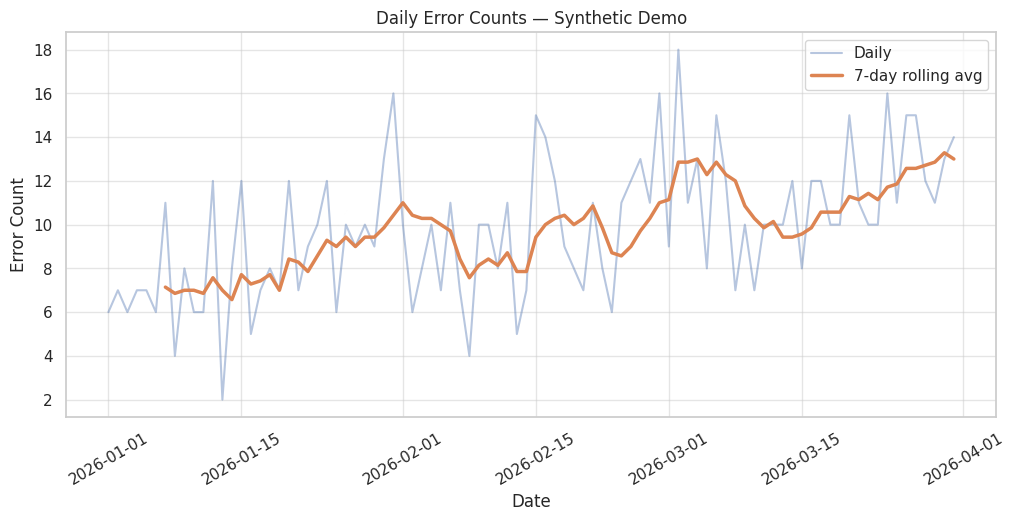

In [56]:
## 56

import numpy as np

# Simulate 90 days of daily error counts (your real pipeline would track this)
np.random.seed(42)
fake_daily = pd.DataFrame({
    'date': pd.date_range('2026-01-01', periods=90, freq='D'),
    'errors_per_day': np.random.poisson(8, 90) + np.linspace(0, 5, 90).astype(int)
})

# Compute 7-day rolling average — Day 64 trick
fake_daily['rolling_7d'] = fake_daily['errors_per_day'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=fake_daily, x='date', y='errors_per_day', label='Daily', alpha=0.4, ax=ax)
sns.lineplot(data=fake_daily, x='date', y='rolling_7d', label='7-day rolling avg', linewidth=2.5, ax=ax)

ax.set_title('Daily Error Counts — Synthetic Demo')
ax.set_xlabel('Date')
ax.set_ylabel('Error Count')
ax.legend()
plt.tick_params(axis='x', rotation=30)
plt.show()

FacetGrid — small multiples

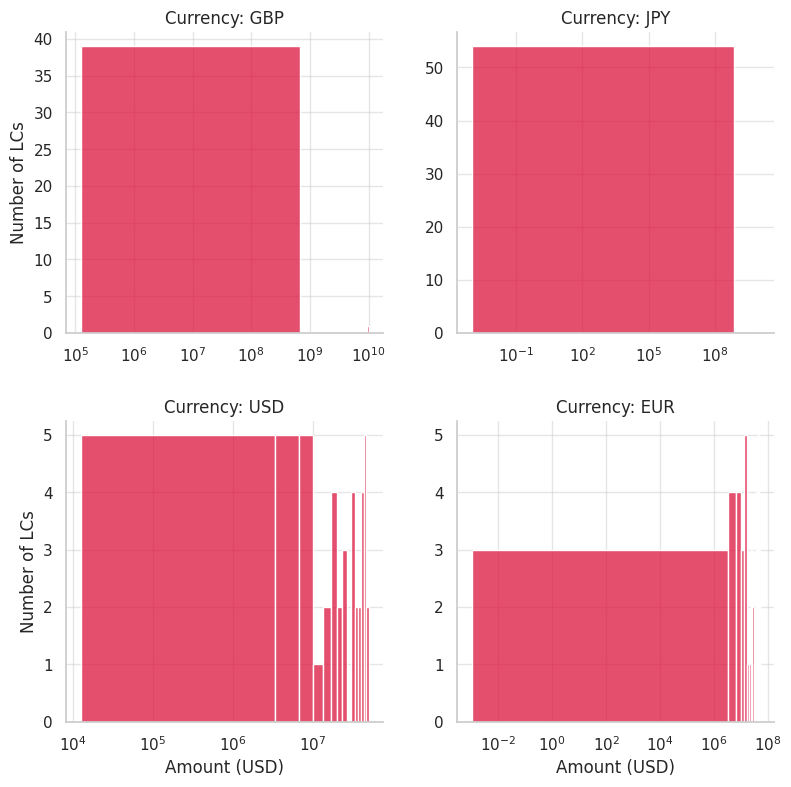

In [57]:
## 57
df_facet = df.copy()
df_facet['amount_clean'] = amount_clean
df_facet = df_facet.query("amount_clean > 0").dropna(subset=['amount_clean', 'currency'])
df_facet = df_facet[df_facet['currency'].isin(['USD', 'EUR', 'GBP', 'JPY'])]

grid = sns.FacetGrid(
    data=df_facet,
    col='currency',
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False
)

grid.map(sns.histplot, 'amount_clean', bins=15, color='#DC143C')

grid.set_titles('Currency: {col_name}')
grid.set_axis_labels('Amount (USD)', 'Number of LCs')

for ax in grid.axes.flatten():
    ax.set_xscale('log')

plt.show()

The corrected version

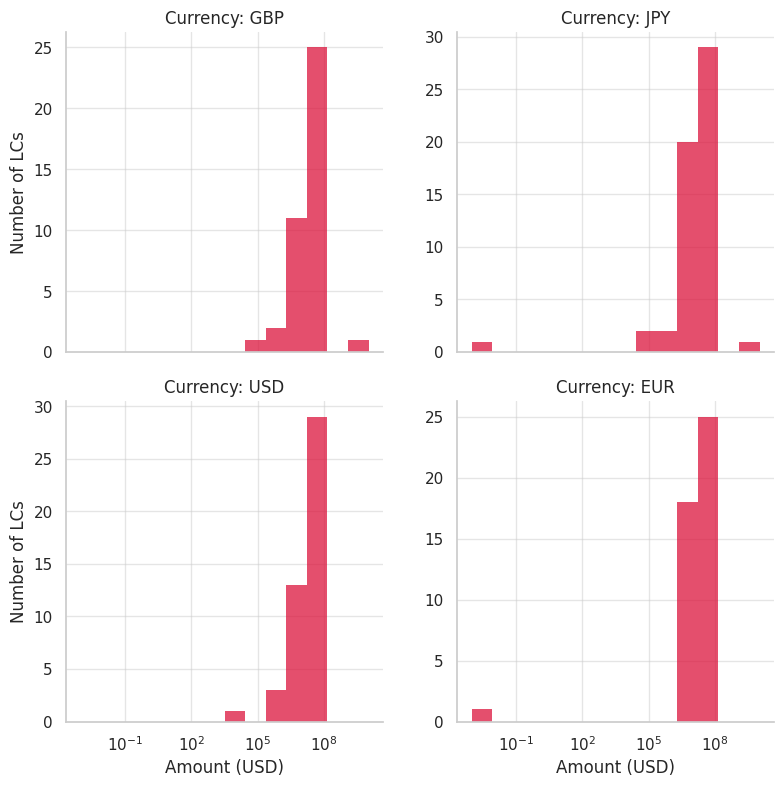

In [58]:
## 58
import numpy as np

# Build log bins from the FULL dataset's range
positive_amounts = df_facet['amount_clean']
log_bins = np.logspace(
    np.log10(positive_amounts.min()),
    np.log10(positive_amounts.max()),
    15
)

grid = sns.FacetGrid(
    data=df_facet,
    col='currency',
    col_wrap=2,
    height=4,
    sharex=True,    # NOW we share — same bins, same axis = fair comparison
    sharey=False
)

grid.map(sns.histplot, 'amount_clean', bins=log_bins, color='#DC143C')

grid.set_titles('Currency: {col_name}')
grid.set_axis_labels('Amount (USD)', 'Number of LCs')

for ax in grid.axes.flatten():
    ax.set_xscale('log')

plt.show()

 Two-dimensional FacetGrid

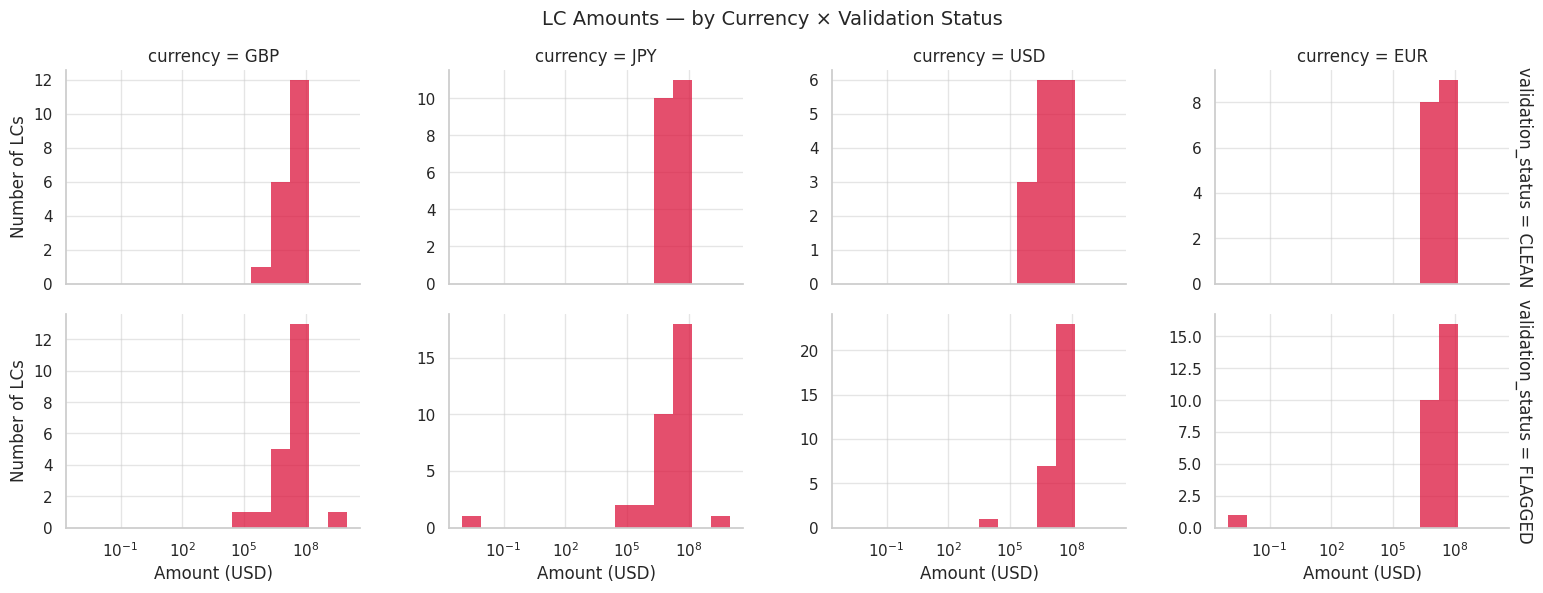

In [59]:
## 59
df_facet2 = df.copy()
df_facet2['amount_clean'] = amount_clean
df_facet2 = df_facet2.query("amount_clean > 0").dropna(subset=['amount_clean', 'currency', 'validation_status'])
df_facet2 = df_facet2[df_facet2['currency'].isin(['USD', 'EUR', 'GBP', 'JPY'])]

log_bins = np.logspace(
    np.log10(df_facet2['amount_clean'].min()),
    np.log10(df_facet2['amount_clean'].max()),
    15
)

grid = sns.FacetGrid(
    data=df_facet2,
    row='validation_status',
    col='currency',
    height=3,
    aspect=1.3,
    sharex=True,
    sharey=False,
    margin_titles=True
)

grid.map(sns.histplot, 'amount_clean', bins=log_bins, color='#DC143C')

for ax in grid.axes.flatten():
    ax.set_xscale('log')

grid.set_axis_labels('Amount (USD)', 'Number of LCs')
grid.figure.subplots_adjust(top=0.88)
grid.figure.suptitle('LC Amounts — by Currency × Validation Status', fontsize=14)

plt.show()

# DAY 72 - Polish, Themes & Export

In [60]:
## 60

# Block 1 — Define the project palette
# Single source of truth for ALL chart colors going forward.
# Severity entries (CRITICAL/HIGH/MEDIUM/LOW/NONE) match SEVERITY_COLORS in constants.py.
# 'flagged' and 'clean' duplicate 'high'/'none' on purpose — semantic naming.
# Code reads like English: PALETTE['flagged'] for the flagged slice, not PALETTE['high'].
PIPELINE_PALETTE = {
    'critical':   '#8B0000',  # Severity (RAG)
    'high':       '#DC143C',
    'medium':     '#FFA500',
    'low':        '#FFD700',
    'none':       '#28A745',
    'flagged':    '#DC143C',  # Status — duplicate of 'high' but semantic
    'clean':      '#28A745',  # Status — duplicate of 'none' but semantic
    'primary':    '#1F4E79',  # Deep banking blue — titles, headers
    'secondary':  '#7F7F7F',  # Gray — axis text, gridlines
    'accent':     '#5B9BD5',  # Light blue — highlights
}

print(PIPELINE_PALETTE)


{'critical': '#8B0000', 'high': '#DC143C', 'medium': '#FFA500', 'low': '#FFD700', 'none': '#28A745', 'flagged': '#DC143C', 'clean': '#28A745', 'primary': '#1F4E79', 'secondary': '#7F7F7F', 'accent': '#5B9BD5'}


In [61]:
## 61

# Block 2 — Apply the seaborn theme GLOBALLY
# style='whitegrid'  -> white background + light gridlines (standard for reports)
# context='talk'     -> auto-scales fonts/lines ~1.3x for slide-deck readability
# font_scale=0.9     -> dials back 'talk' slightly so it isn't too aggressive on smaller charts
# Order matters: this MUST run before plt.subplots() to take effect on the next chart.
sns.set_theme(
    style='whitegrid',
    context='talk',
    font_scale=0.9
)

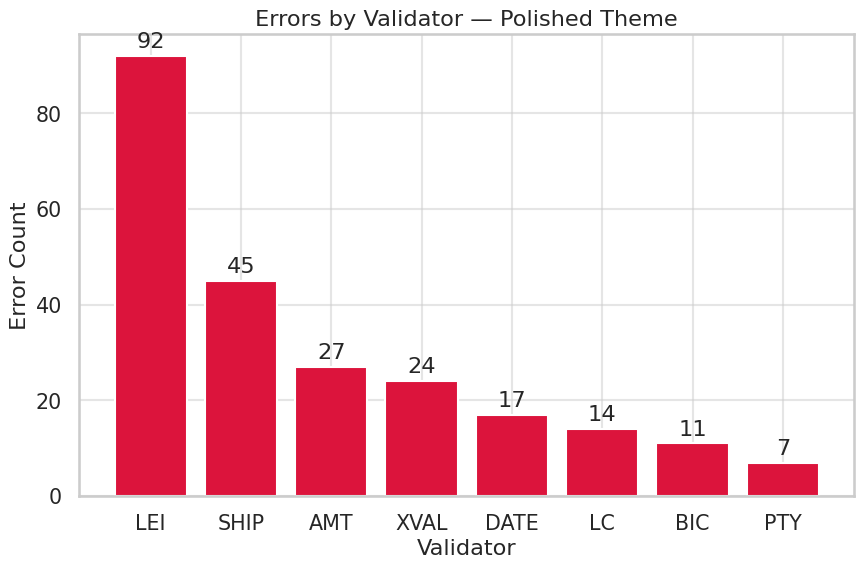

In [62]:
## 62

# Block 3 — Replot validator bar chart with the polished theme
# Same data structure as Day 66. The visible difference is purely stylistic:
# bigger fonts, white background, light grid, single semantic color from the palette.
# color=[PIPELINE_PALETTE['high']] * len(...) creates a list with one color
# repeated for every bar — uniform color, professional look.

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
errors_per_validator.index,
errors_per_validator.values,
color=[PIPELINE_PALETTE['high']] * len(errors_per_validator) # 8
)
ax.bar_label(bars, padding=3)
ax.set_title('Errors by Validator — Polished Theme')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

plt.show()



Annotations: highlighting WHAT MATTERS

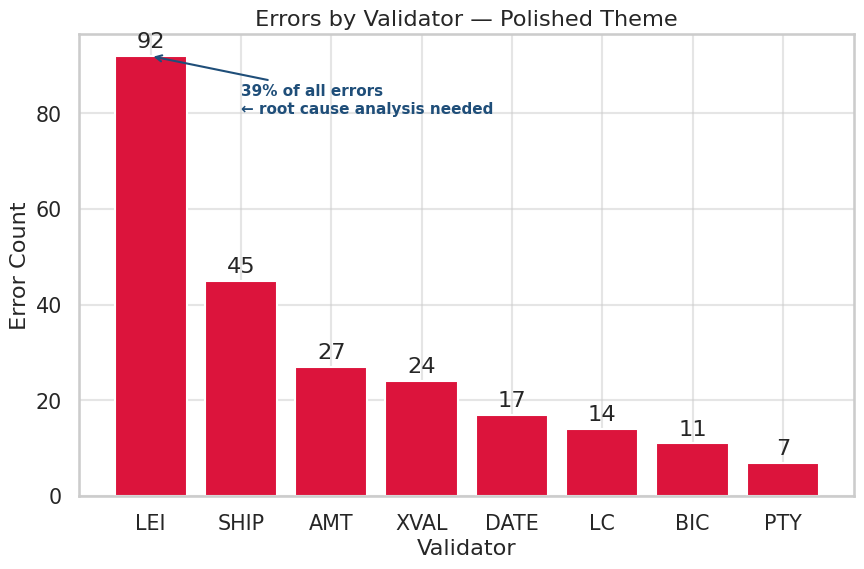

In [63]:
## 63

# Add annotation to the LEI bar
# ax.annotate() places text + an arrow on the chart at specific coordinates
# Two coordinate sets are needed:
#   xy=(x, y)        -> WHERE the arrow tip lands (the data point)
#   xytext=(x, y)    -> WHERE the text label sits
# Coordinates are in DATA units (validator name on x, error count on y)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    errors_per_validator.index,
    errors_per_validator.values,
    color=[PIPELINE_PALETTE['high']] * len(errors_per_validator)
)
ax.bar_label(bars, padding=3)

# THE NEW LINE — annotate LEI bar
ax.annotate(
    text='39% of all errors\n← root cause analysis needed',
    xy=('LEI', 92),                 # Arrow points to top of LEI bar
    xytext=('SHIP', 80),            # Text starts above SHIP bar
    fontsize=11,
    color=PIPELINE_PALETTE['primary'],
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color=PIPELINE_PALETTE['primary'],
        lw=1.5
    )
)

ax.set_title('Errors by Validator — Polished Theme')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

plt.show()




Grid customization & axis polish

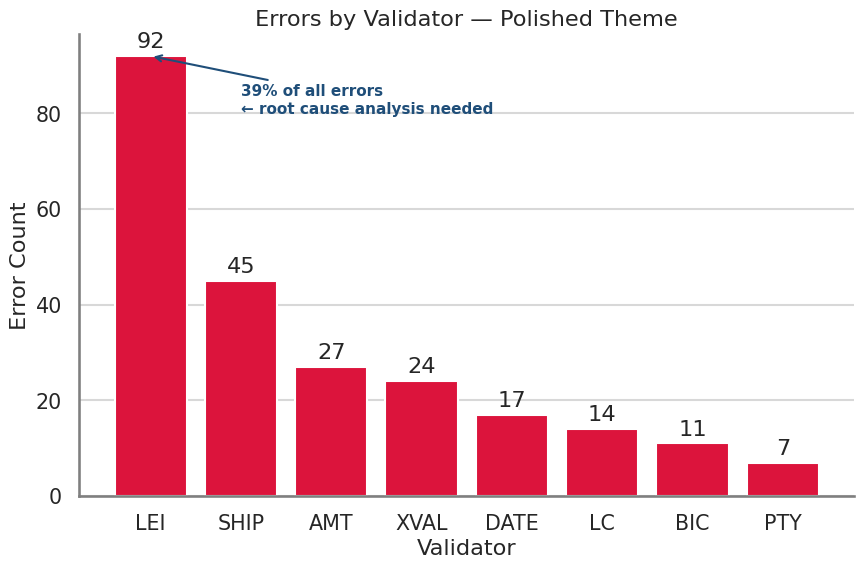

In [64]:
## 64

# Chunk 6 — Polished version with grid + axis customization
# Three improvements over Chunk 5:
#   1. ax.grid(...) — lighter grid color + only horizontal lines (vertical noise removed)
#   2. ax.spines[...].set_visible(False) — remove top + right borders ("axis spines")
#   3. ax.set_axisbelow(True) — pushes grid behind bars (otherwise grid lines on top of bars)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    errors_per_validator.index,
    errors_per_validator.values,
    color=[PIPELINE_PALETTE['high']] * len(errors_per_validator)
)
ax.bar_label(bars, padding=3)

# Annotation (same as Chunk 5)
ax.annotate(
    text='39% of all errors\n← root cause analysis needed',
    xy=('LEI', 92),
    xytext=('SHIP', 80),
    fontsize=11,
    color=PIPELINE_PALETTE['primary'],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PIPELINE_PALETTE['primary'], lw=1.5)
)

# Grid customization — only horizontal, soft gray, behind bars
ax.grid(axis='y', alpha=0.3, color=PIPELINE_PALETTE['secondary'])
ax.grid(axis='x', visible=False)         # No vertical gridlines
ax.set_axisbelow(True)                   # Grid behind bars, not on top

# Spine cleanup — remove top and right borders for breathing room
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(PIPELINE_PALETTE['secondary'])
ax.spines['bottom'].set_color(PIPELINE_PALETTE['secondary'])

ax.set_title('Errors by Validator — Polished Theme')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

plt.show()


Saving as high-quality PDF for board reports

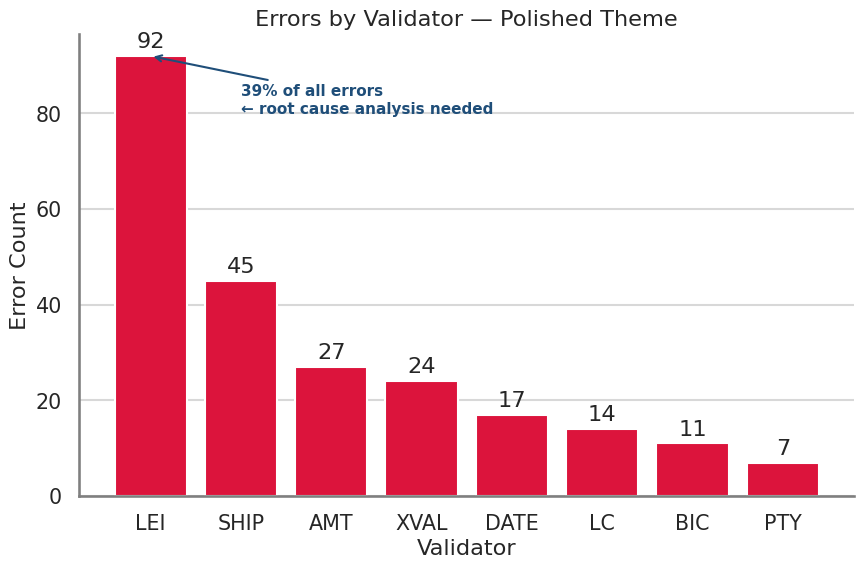

In [65]:
## 65

# Chunk 7 — Save the polished chart as PDF and PNG
# Two saves: one PDF for reports, one PNG for slides/email
# bbox_inches='tight' trims the white margin around the figure
# Using fig.savefig (not plt.savefig) — explicit OOP discipline

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    errors_per_validator.index,
    errors_per_validator.values,
    color=[PIPELINE_PALETTE['high']] * len(errors_per_validator)
)
ax.bar_label(bars, padding=3)

ax.annotate(
    text='39% of all errors\n← root cause analysis needed',
    xy=('LEI', 92),
    xytext=('SHIP', 80),
    fontsize=11,
    color=PIPELINE_PALETTE['primary'],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PIPELINE_PALETTE['primary'], lw=1.5)
)

ax.grid(axis='y', alpha=0.3, color=PIPELINE_PALETTE['secondary'])
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(PIPELINE_PALETTE['secondary'])
ax.spines['bottom'].set_color(PIPELINE_PALETTE['secondary'])

ax.set_title('Errors by Validator — Polished Theme')
ax.set_xlabel('Validator')
ax.set_ylabel('Error Count')

## Chunk 7 — Export to PDF + PNG (the final move)
# Save to BOTH formats — one cell, two outputs
fig.savefig('../data/output/validator_chart.pdf', bbox_inches='tight')
fig.savefig('../data/output/validator_chart.png', dpi=300, bbox_inches='tight')

plt.show()


# ===============  DAY 73 ==============

In [66]:
## 66
# Verify both loaded correctly
print("SEVERITY_COLORS:")
print(SEVERITY_COLORS)
print()
print("PIPELINE_PALETTE:")
print(PIPELINE_PALETTE)

SEVERITY_COLORS:
{'CRITICAL': '#8B0000', 'HIGH': '#DC143C', 'MEDIUM': '#FFA500', 'LOW': '#FFD700', 'NONE': '#28A745'}

PIPELINE_PALETTE:
{'critical': '#8B0000', 'high': '#DC143C', 'medium': '#FFA500', 'low': '#FFD700', 'none': '#28A745', 'flagged': '#DC143C', 'clean': '#28A745', 'primary': '#1F4E79', 'secondary': '#7F7F7F', 'accent': '#5B9BD5'}


## Chunk 2 - 3: The scaffold

Time to assemble. We start with the empty 2x2 grid + suptitle + subtitle
+ tight_layout. Same pattern as Day 68, but with Day 72 polish baked in.

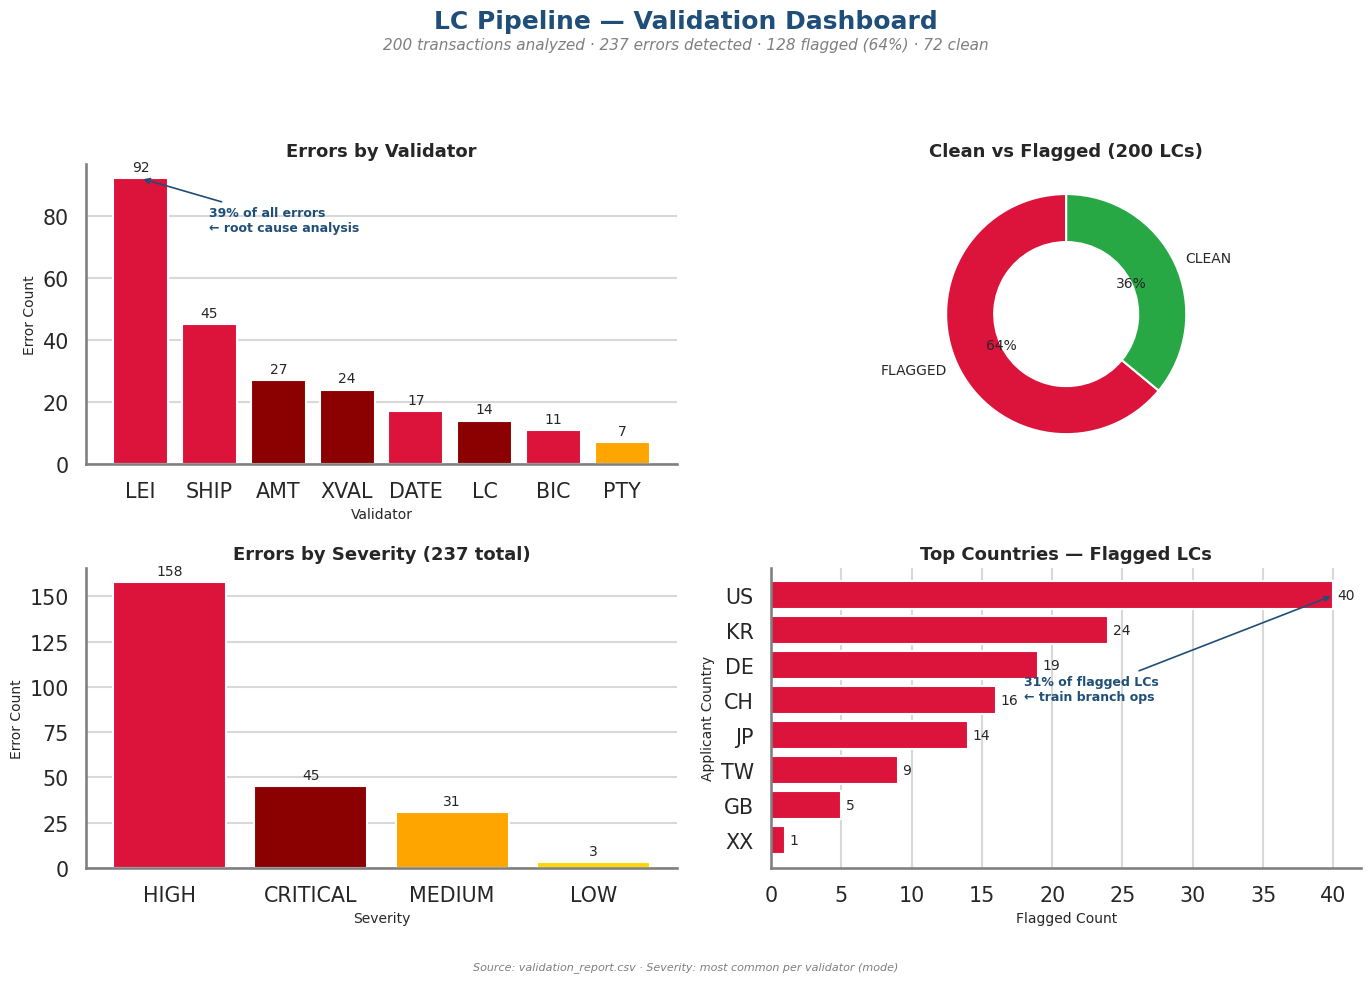

In [67]:
## 67

# Chunk 2 (FINAL) — Capstone scaffold with dynamic subtitle, simple footer
# Subtitle: data-driven (auto-updates if df changes)
# Footer: static text (no date — keeps it simple for learning project)

# Step 1: Compute the live metrics from the data
total_transactions = len(df)
total_errors = df['error_count'].sum()
flagged_count = (df['validation_status'] == 'FLAGGED').sum()
clean_count = (df['validation_status'] == 'CLEAN').sum()
flagged_pct = flagged_count / total_transactions * 100

# Step 2: Build the subtitle (DYNAMIC — uses computed values)
subtitle_text = (
    f'{total_transactions} transactions analyzed · '
    f'{total_errors} errors detected · '
    f'{flagged_count} flagged ({flagged_pct:.0f}%) · '
    f'{clean_count} clean'
)

# Step 3: Static footer (no date)
footer_text = (
    'Source: validation_report.csv · '
    'Severity: most common per validator (mode)'
)

# Step 4: Build the figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

fig.suptitle(
    'LC Pipeline — Validation Dashboard',
    fontsize=18,
    fontweight='bold',
    color=PIPELINE_PALETTE['primary'],
    y=0.98
)

fig.text(
    0.5, 0.94,
    subtitle_text,
    ha='center',
    fontsize=11,
    color=PIPELINE_PALETTE['secondary'],
    style='italic'
)

fig.text(
    0.5, 0.02,
    footer_text,
    ha='center',
    fontsize=8,
    color=PIPELINE_PALETTE['secondary'],
    style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])

##  Chunk 3 — Fill axes[0, 0]: Validator Pareto with annotation
# Polished version with all Day 72 treatments baked in:
#   - Severity-coded bar colors (from Day 66's bar_colors)
#   - Value labels on each bar
#   - Annotation pointing at LEI with insight
#   - Soft horizontal grid, no vertical grid
#   - Top + right spines hidden
#   - axisbelow=True so grid sits behind bars

# Re-run the scaffold first (Chunk 2 code), then ADD this block to fill axes[0,0]
# Or merge them into one big cell — your call

ax_tl = axes[0, 0]   # Top-left subplot

bars_tl = ax_tl.bar(
    errors_per_validator.index,
    errors_per_validator.values,
    color=bar_colors                      # From Day 66 — severity-mode colors
)

# Value labels above each bar
ax_tl.bar_label(bars_tl, padding=3, fontsize=10)

# Annotation — the LEI insight (39% of all errors)
lei_pct = errors_per_validator['LEI'] / errors_per_validator.sum() * 100

ax_tl.annotate(
    text=f'{lei_pct:.0f}% of all errors\n← root cause analysis',
    xy=('LEI', errors_per_validator['LEI']),
    xytext=('SHIP', 75),
    fontsize=9,
    color=PIPELINE_PALETTE['primary'],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PIPELINE_PALETTE['primary'], lw=1.2)
)

# Title and labels
ax_tl.set_title('Errors by Validator', fontsize=13, fontweight='bold')
ax_tl.set_xlabel('Validator', fontsize=10)
ax_tl.set_ylabel('Error Count', fontsize=10)

# Day 72 polish — grid + spines
ax_tl.grid(axis='y', alpha=0.3, color=PIPELINE_PALETTE['secondary'])
ax_tl.grid(axis='x', visible=False)
ax_tl.set_axisbelow(True)
ax_tl.spines['top'].set_visible(False)
ax_tl.spines['right'].set_visible(False)
ax_tl.spines['left'].set_color(PIPELINE_PALETTE['secondary'])
ax_tl.spines['bottom'].set_color(PIPELINE_PALETTE['secondary'])


##  Chunk 4 — Top-right panel: Donut chart for Clean vs Flagged
# Pie/donut charts use POLAR layout, not Cartesian — so no spines/grid to fix.
# Just colors, labels, and the wedgeprops trick to create the hole.

ax_tr = axes[0, 1]   # Top-right subplot

# Use PIPELINE_PALETTE directly — semantic naming pays off here:
#   colors[0] for FLAGGED (= 'flagged' alias)
#   colors[1] for CLEAN   (= 'clean' alias)
# status_counts.index order is ['FLAGGED', 'CLEAN'] (FLAGGED first because larger)
donut_colors = [PIPELINE_PALETTE['flagged'], PIPELINE_PALETTE['clean']]

ax_tr.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=donut_colors,
    autopct='%1.0f%%',                   # Percentage with 0 decimals
    startangle=90,                       # Start at 12 o'clock
    wedgeprops={'width': 0.4},           # Hole in the middle = donut
    textprops={'fontsize': 10}           # Labels and percentages
)

ax_tr.set_title(
    f'Clean vs Flagged ({total_transactions} LCs)',
    fontsize=13,
    fontweight='bold'
)

## Chunk 5 — Bottom-left panel: Errors by Severity — Fill axes[1, 0]: Severity breakdown bars
# Bars colored by their own severity using SEVERITY_COLORS dict lookup.
# Since X-axis labels ARE severity names, we map directly: severity → color.

ax_bl = axes[1, 0]   # Bottom-left subplot

# Build the color list — one color per bar, in the SAME order as severity_counts.index
# severity_counts.index = ['HIGH', 'CRITICAL', 'MEDIUM', 'LOW']
# We look up each label in SEVERITY_COLORS to get its hex code

severity_bar_colors = [SEVERITY_COLORS[sev] for sev in severity_counts.index]

bars_bl = ax_bl.bar(
    severity_counts.index,
    severity_counts.values,
    color=severity_bar_colors
)

ax_bl.bar_label(bars_bl, padding=3, fontsize=10)

# Title and labels
ax_bl.set_title(
    f'Errors by Severity ({total_errors} total)',
    fontsize=13,
    fontweight='bold'
)
ax_bl.set_xlabel('Severity', fontsize=10)
ax_bl.set_ylabel('Error Count', fontsize=10)

# Day 72 polish — same recipe as top-left
ax_bl.grid(axis='y', alpha=0.3, color=PIPELINE_PALETTE['secondary'])
ax_bl.grid(axis='x', visible=False)
ax_bl.set_axisbelow(True)
ax_bl.spines['top'].set_visible(False)
ax_bl.spines['right'].set_visible(False)
ax_bl.spines['left'].set_color(PIPELINE_PALETTE['secondary'])
ax_bl.spines['bottom'].set_color(PIPELINE_PALETTE['secondary'])


# Chunk 6 — Bottom-right panel: Top countries with annotation
# Horizontal bars (.barh) because country codes are short but we have many
# Single uniform crimson — country has no severity meaning, color = signal noise
# Second annotation pointing at US (the dominant source)

ax_br = axes[1, 1]   # Bottom-right subplot

bars_br = ax_br.barh(
    flagged_by_country.index,
    flagged_by_country.values,
    color=PIPELINE_PALETTE['flagged']
)

ax_br.bar_label(bars_br, padding=3, fontsize=10)

# Compute the dominant country dynamically (top of the series)
top_country = flagged_by_country.idxmax()
top_country_count = flagged_by_country.max()
top_country_pct = top_country_count / flagged_by_country.sum() * 100

# Annotation pointing at US (or whichever country is biggest)
ax_br.annotate(
    text=f'{top_country_pct:.0f}% of flagged LCs\n← train branch ops',
    xy=(top_country_count, top_country),
    xytext=(top_country_count * 0.45, 'CH'),   # Land in empty space mid-chart
    fontsize=9,
    color=PIPELINE_PALETTE['primary'],
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PIPELINE_PALETTE['primary'], lw=1.2)
)

ax_br.set_title(
    'Top Countries — Flagged LCs',
    fontsize=13,
    fontweight='bold'
)
ax_br.set_xlabel('Flagged Count', fontsize=10)
ax_br.set_ylabel('Applicant Country', fontsize=10)

# Day 72 polish — note: for HORIZONTAL bars, grid goes on X axis (where values live)
ax_br.grid(axis='x', alpha=0.3, color=PIPELINE_PALETTE['secondary'])
ax_br.grid(axis='y', visible=False)
ax_br.set_axisbelow(True)
ax_br.spines['top'].set_visible(False)
ax_br.spines['right'].set_visible(False)
ax_br.spines['left'].set_color(PIPELINE_PALETTE['secondary'])
ax_br.spines['bottom'].set_color(PIPELINE_PALETTE['secondary'])

plt.tight_layout(rect=[0, 0.04, 1, 0.92])

fig.savefig('../data/output/lc_dashboard_v1.pdf', bbox_inches='tight')
fig.savefig('../data/output/lc_dashboard_v1.png', dpi=300, bbox_inches='tight')

plt.show()

